# Predicting “It Bags” Using Resale and Attention Signals

This notebook builds a dataset of luxury handbag models and trains
classification models to predict whether a bag becomes an “It Bag”
(top resale percentile).

Pipeline:
1. Load cached dataset
2. Feature engineering
3. Train/test split
4. Model training
5. Evaluation
6. Feature analysis

# Environment Setup

## Dependencies

In [ ]:
!pip install pytrends
!pip install "urllib3<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.


In [ ]:
import os, re, time, random, requests, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import time

from google.colab import files
from datetime import datetime, timezone
from pytrends.request import TrendReq
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

In [ ]:
#define pytrends with headers, so that Google does not block the request
requests_args = {
    "headers": {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/108.0.0.0 Safari/537.36"
        )
    }
}
# Only need to run this once, the rest of requests will use the same session.
pytrend = TrendReq(
    hl="en-US",
    tz=360,
    retries=5,          # number of retries
    backoff_factor=2,   # exponential backoff: 1s, 2s, 4s, 8s, ...
    requests_args=requests_args,
)


## Set cache flag

In [ ]:
USE_AGG_CACHE = True

### Detect Cached Data Files

This section detects the required input files for the notebook, including cached Rebag listings, cached Google Trends features, and the master Excel file containing the handbag model list. By checking multiple possible file paths, the notebook can run more easily across local and Colab environments without manual path edits.

#### Run the below cell and upload the 3 files (rebag_listings_latest.parquet, google_trends_features.csv, Value Retention data.xlsx) if rerunning a new instance of the notebook. Once cached, this cell does not need to be run.

### Upload or Detect Cached Data

If cached files are already present in the runtime, the notebook will reuse them.  
Otherwise you will be prompted to upload the required files.

In [ ]:
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

required_files = {
    "Value Retention data.xlsx": [
        "Value Retention data.xlsx",
        "/content/Value Retention data.xlsx",
    ]
}

if USE_AGG_CACHE:
    required_files["rebag_listings_latest.parquet"] = [
        "data/cache/rebag_listings_latest.parquet",
        "rebag_listings_latest.parquet",
        "/content/rebag_listings_latest.parquet",
    ]
    required_files["google_trends_features.csv"] = [
        "google_trends_features.csv",
        "/content/google_trends_features.csv",
    ]

resolved_paths = {}
missing_files = []

for fname, candidates in required_files.items():
    path = first_existing(candidates)
    if path is not None:
        resolved_paths[fname] = path
    else:
        missing_files.append(fname)

if missing_files:
    print("Missing files detected:")
    for f in missing_files:
        print(f"  - {f}")
    print("\nPlease upload the missing file(s).")
    uploaded = files.upload()

    for fname, candidates in required_files.items():
        if fname not in resolved_paths:
            path = first_existing(candidates)
            if path is not None:
                resolved_paths[fname] = path

    still_missing = [f for f in required_files if f not in resolved_paths]
    if still_missing:
        raise FileNotFoundError(
            "Still missing required file(s): " + ", ".join(still_missing)
        )
else:
    print("All required files already found.")

VALUE_RETENTION_PATH = resolved_paths["Value Retention data.xlsx"]
AGG_CACHE_PATH = resolved_paths.get("rebag_listings_latest.parquet")
TREND_CACHE_PATH = resolved_paths.get("google_trends_features.csv")

print("\nResolved paths:")
print("VALUE_RETENTION_PATH:", VALUE_RETENTION_PATH)
print("AGG_CACHE_PATH:", AGG_CACHE_PATH)
print("TREND_CACHE_PATH:", TREND_CACHE_PATH)

All required files already found.

Resolved paths:
VALUE_RETENTION_PATH: Value Retention data.xlsx
AGG_CACHE_PATH: rebag_listings_latest.parquet
TREND_CACHE_PATH: google_trends_features.csv


In [ ]:
assert VALUE_RETENTION_PATH is not None, "Missing Value Retention data.xlsx"

# Prefer parquet cache first
USE_AGG_CACHE = True

if USE_AGG_CACHE:
    assert USE_AGG_CACHE is not None, "Missing rebag_listings_latest.parquet"
    assert TREND_CACHE_PATH is not None, "Missing google_trends_features.csv"
    print("Using cached aggregated data files.")
else:
    print("USE_AGG_CACHE=False, notebook will rebuild data from scraping / preprocessing steps.")

Using cached aggregated data files.


# Setup helpers

## Rebag Scraping Helpers

This section defines constants and helper functions used to query the Rebag search API and cache per-query results locally.

In [ ]:
CACHE_DIR = "data/raw_rebag"
os.makedirs(CACHE_DIR, exist_ok=True)

API_URL = "https://proxy.rebag.groupbycloud.com/rebag/api/search/"

HEADERS = {
    "accept": "application/json, text/plain, */*",
    "content-type": "application/json",
    "origin": "https://shop.rebag.com",
    "referer": "https://shop.rebag.com/",
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36",
    "x-application-type": "search",
}

BASE_PAYLOAD = {
    "collection": "ProductsProduction",
    "area": "ProductionRb",
    "skip": "0",  # keep as STRING like HAR
    "query": None,
    "refinements": [],
    "sorts": [],
    "preFilter": "attributes.publishedOnChannel:ANY(\"true\") AND NOT attributes.tags:ANY(\"pfs:hidden\") AND availability:ANY(\"IN_STOCK\") AND attributes.pf_t_first_look_hidden:ANY(\"bc-filter-General View\") AND attributes.collectionIds:ANY(\"17987005\")",
    "pageCategories": [],
    "pageSize": 48,
}

# ---------- helper functions ----------------------
def parse_metafields_list(metafields_text_list):
    """
    Input: list like ["condition:Great", "estimated_retail_price:3950", ...]
    Output: dict { "condition": "Great", "estimated_retail_price": "3950", ... }
    """
    out = {}
    if not metafields_text_list:
        return out
    for s in metafields_text_list:
        if not isinstance(s, str) or ":" not in s:
            continue
        k, v = s.split(":", 1)
        out[k.strip()] = v.strip()
    return out

def safe_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "None", "nan"]:
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def extract_meta_tag(tags, prefix):
    # returns the FIRST tag that starts with prefix, stripped of prefix
    if not tags:
        return None
    for t in tags:
        if isinstance(t, str) and t.startswith(prefix):
            return t[len(prefix):]
    return None

def safe_cache_name(query: str) -> str:
    """
    Make a filesystem-safe cache filename stem from a query.
    Replaces anything that's not [A-Za-z0-9_-] with underscores.
    """
    stem = re.sub(r"[^\w\-]+", "_", query.strip())
    stem = re.sub(r"_+", "_", stem).strip("_")
    return stem or "query"

def rebag_search_one_model(query: str, page_size=48, max_pages=5, sleep_range=(0.8, 1.6), use_cache=True):
    cache_file = os.path.join(CACHE_DIR, f"{safe_cache_name(query)}.json")

    # -----------------------
    # LOAD FROM CACHE IF EXISTS
    # -----------------------
    if use_cache and os.path.exists(cache_file):
        print("Loading from cache:", cache_file)
        try:
            with open(cache_file, "r") as f:
                rows = json.load(f)

            if isinstance(rows, list) and len(rows) > 0:
                return pd.DataFrame(rows)
            else:
                print("Cache file is empty or invalid structure, rescraping:", cache_file)

        except (json.JSONDecodeError, OSError) as e:
            print(f"Cache read failed for {cache_file}, rescraping. Error: {e}")

    rows = []

    payload = dict(BASE_PAYLOAD)
    payload["query"] = query
    payload["pageSize"] = page_size

    for page in range(max_pages):
        payload["skip"] = str(page * page_size)

        r = requests.post(API_URL, headers=HEADERS, json=payload, timeout=30)

        if r.status_code != 200:
            print("Status:", r.status_code)
            print(r.text[:500])
            r.raise_for_status()

        data = r.json()
        records = data.get("records", [])
        if not records:
            break

        for rec in records:
            meta = rec.get("allMeta", {}) or {}
            attrs = meta.get("attributes") or {}

            price = (meta.get("priceInfo", {}) or {}).get("price")
            title = meta.get("title")
            brand = (meta.get("brands") or [None])[0]
            handle = (((attrs.get("handle") or {}).get("text")) or [None])[0]

            # tags + meta-model/meta-size
            tags = (((attrs.get("tags") or {}).get("text")) or [])
            meta_model = extract_meta_tag(tags, "meta-model-")
            meta_size  = extract_meta_tag(tags, "meta-size-")

            # metafields -> dict
            metafields_text = (((attrs.get("metafields") or {}).get("text")) or [])
            mf = parse_metafields_list(metafields_text)

            # favorites_count is separate
            favorites = (((attrs.get("favorites_count") or {}).get("numbers")) or [np.nan])[0]

            # date information
            created_at = (((attrs.get("createdAt") or {}).get("text")) or [None])[0]
            published_at = (((attrs.get("publishedAt") or {}).get("text")) or [None])[0]
            updated_at = (((attrs.get("updatedAt") or {}).get("text")) or [None])[0]

            rows.append({
                "query": query,
                "brand": brand,
                "title": title,
                "handle": handle,
                "price": safe_float(price),  # listing price from priceInfo.price
                "estimated_retail_price": safe_float(mf.get("estimated_retail_price")),
                "marketplace_clearing_price": safe_float(mf.get("marketplace_clearing_price")),
                "original_price": safe_float(mf.get("original_price")),
                "views_counter": safe_float(mf.get("views_counter")),
                "favorites_count": safe_float(favorites),
                "condition": mf.get("condition"),
                "exterior_material": mf.get("exterior_material"),
                "exterior_color": mf.get("exterior_color"),
                "silhouette": mf.get("silhouette"),
                "meta_model": meta_model,
                "meta_size": meta_size,
                "created_at": created_at,
                "published_at": published_at,
                "updated_at": updated_at,
                "batch_publish_date": mf.get("batch_publish_date"),
            })

        time.sleep(random.uniform(*sleep_range))

    # -----------------------
    # SAVE CACHE
    # -----------------------
    if use_cache:
        with open(cache_file, "w") as f:
            json.dump(rows, f)

    return pd.DataFrame(rows)

## Listing Filtering Helpers

These helper functions filter raw resale listings to ensure that only relevant items are used for feature construction.

Because search queries can return loosely related products (e.g., accessories, variations, or unrelated models), we filter listings based on keywords in the listing title. This step improves data quality before aggregating listings into model-level features.

In [ ]:
def filter_listings(df, include_terms, exclude_terms=None):
    """
    Filter raw listings using title keywords.

    include_terms: list of keywords that must appear in the title
    exclude_terms: optional keywords that should not appear

    Returns a filtered dataframe of listings.
    """

    title = df["title"].fillna("").str.lower()
    inc = np.ones(len(df), dtype=bool)
    for t in include_terms:
        inc &= title.str.contains(re.escape(t), case=False)
    exc = np.zeros(len(df), dtype=bool)
    for t in (exclude_terms or []):
        exc |= title.str.contains(re.escape(t), case=False)
    return df[inc & (~exc) & df["price"].notna()].copy()


## Data Cleaning Helpers

These helper functions remove noise and outliers from the resale data before feature construction.
Because resale listings may include extreme prices (e.g., damaged items, mispriced listings, or rare collector listings), we apply a standard interquartile range (IQR) filter to remove extreme values. This helps ensure that model features such as median resale price are not distorted by outliers.

In [ ]:
def iqr_filter(prices):
    """
    Remove outliers using the interquartile range (IQR) rule.

    Keeps values within:
        Q1 - 1.5 * IQR  to  Q3 + 1.5 * IQR
    """

    q1 = prices.quantile(0.25)
    q3 = prices.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return prices[(prices >= lo) & (prices <= hi)]

## Label Construction Helpers

These helper functions compute resale-based target statistics for each bag model.

For a given model, we first filter raw listings to keep only relevant products, then remove extreme price outliers using the IQR rule, and finally compute the median resale price. We compare this median resale value to MSRP to estimate value retention, which is used as a proxy for whether a bag exhibits “It Bag” behavior.

In [ ]:
def compute_label_for_model(df_listings, msrp, include_terms, exclude_terms=None):
    """
    Compute resale-based label statistics for a single bag model.

    Steps:
    1. Filter listings by title keywords
    2. Remove price outliers with the IQR rule
    3. Compute median resale price
    4. Compute retention = median_resale / MSRP
    """

    keep = filter_listings(df_listings, include_terms, exclude_terms)
    if keep.empty:
        return {
            "n_listings": 0,
            "median_resale": None,
            "retention": None
        }
    prices = keep["price"].astype(float)
    prices_f = iqr_filter(prices)

    if prices_f.empty:
        return {
            "n_listings": len(prices),
            "median_resale": None,
            "retention": None
        }

    median_resale = float(prices_f.median())
    return {
        "n_listings": int(len(prices_f)),
        "median_resale": median_resale,
        "retention": median_resale / float(msrp)
    }


## Feature Engineering Helpers

This section defines helper functions that convert raw listing-level data from Rebag into model-level features used for machine learning.

Each bag model may have many individual resale listings. The function below aggregates those listings into a single row per bag model and computes summary statistics such as median resale price, estimated retail price, attention signals (views and favorites), and listing counts.

These aggregated features form the dataset used to train the classification models that predict whether a bag becomes an “It Bag”.

In [ ]:
def build_model_features(df_listings):
    """
    Convert raw Rebag listing-level data into model-level features.

    Aggregates multiple listings of the same bag model into one row
    containing resale statistics and attention signals.
    """

    # choose a resale price field:
    # marketplace_clearing_price seems closer to “what it clears at” if present;
    # fallback to listing price when missing.
    df = df_listings.copy()
    df["resale_price_proxy"] = df["marketplace_clearing_price"].fillna(df["price"])

    # drop rows with no usable prices
    df = df[df["resale_price_proxy"].notna()].copy()

    # group key
    df["model_key"] = (
        df["brand"].fillna("UNK").astype(str) + " | " +
        df["meta_model"].fillna(df["query"]).astype(str) + " | " +
        df["meta_size"].fillna("NA").astype(str)
    )

    g = df.groupby("model_key")

    feat = g.agg(
        brand=("brand", "first"),
        meta_model=("meta_model", "first"),
        meta_size=("meta_size", "first"),
        n_listings=("resale_price_proxy", "size"),
        median_resale=("resale_price_proxy", "median"),
        median_est_retail=("estimated_retail_price", "median"),
        median_views=("views_counter", "median"),
        median_favorites=("favorites_count", "median"),
        pct_missing_est_retail=("estimated_retail_price", lambda x: float(x.isna().mean())),
    ).reset_index()

    # ratios (guard against divide-by-0 / missing)
    feat["resale_premium"] = feat["median_resale"] / feat["median_est_retail"].replace(0, np.nan)
    feat.loc[feat["median_est_retail"].isna(), "resale_premium"] = np.nan

    # basic transforms for counts
    feat["log_views"] = np.log1p(feat["median_views"])
    feat["log_favorites"] = np.log1p(feat["median_favorites"])

    return feat


# Dataset Preparation

## Load Bag Model Dataset

Load the Excel dataset containing handbag brands and models. Clean column names, remove incomplete rows, and construct unique search queries (Brand + Model) that will be used to collect resale listings.

In [ ]:
models_xl = pd.read_excel("Value Retention data.xlsx", sheet_name="Bag models with size 1000s")
models_xl.columns = [c.strip().lower() for c in models_xl.columns]

models_xl = models_xl.dropna(subset=["brand", "model_family"]).copy()

for col in ["brand", "model_family", "size_variant"]:
    if col in models_xl.columns:
        models_xl[col] = models_xl[col].astype(str).str.strip()

# use saved query if it exists, otherwise build it
if "query" not in models_xl.columns:
    models_xl["query"] = (
        models_xl["brand"]
        + " "
        + models_xl["model_family"]
        + " "
        + models_xl["size_variant"].replace({"nan": ""}).fillna("")
    ).str.strip()
else:
    models_xl["query"] = models_xl["query"].astype(str).str.strip()

queries = models_xl["query"].replace({"nan": pd.NA, "": pd.NA}).dropna().drop_duplicates().tolist()

len(queries), queries[:10]

(1281,
 ['Hermes Birkin 25',
  'Hermes Birkin 30',
  'Hermes Birkin 35',
  'Hermes Birkin 40',
  'Hermes Birkin HAC 40',
  'Hermes Birkin HAC 45',
  'Hermes Birkin HAC 50',
  'Hermes Kelly 20',
  'Hermes Kelly 25',
  'Hermes Kelly 28'])

## Load or Collect Rebag Listing Data

Load cached resale listings if available; otherwise scrape listings from Rebag for each bag model and store the results in a local cache for reuse.

In [ ]:
CACHE_DIR = "data/cache"

os.makedirs(CACHE_DIR, exist_ok=True)

if USE_AGG_CACHE and os.path.exists(AGG_CACHE_PATH):
    print("Loading aggregated cache:", AGG_CACHE_PATH)
    df_listings = pd.read_parquet(AGG_CACHE_PATH)

else:
    print("Cache disabled or not found, scraping fresh data...")

    all_dfs = []

    for q in queries:
        print("Scraping:", q)
        df_q = rebag_search_one_model(q)

        if df_q is not None and len(df_q) > 0:
            df_q["source_query"] = q
            all_dfs.append(df_q)

    if len(all_dfs) == 0:
        raise RuntimeError("No listings scraped.")

    df_listings = pd.concat(all_dfs, ignore_index=True)
    df_listings = df_listings.rename(columns={"model_name": "rebag_model_name"})

    # timestamped cache
    df_listings["scrape_timestamp"] = pd.Timestamp.now(tz="UTC")
    ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    cache_path = os.path.join(CACHE_DIR, f"rebag_listings_{ts}.parquet")

    df_listings.to_parquet(cache_path, index=False)
    df_listings.to_parquet(AGG_CACHE_PATH, index=False)

    print("Saved timestamped cache:", cache_path)
    print("Updated latest cache:", AGG_CACHE_PATH)

    files.download(cache_path)
    print("Downloaded timestamped cache:", cache_path)

    files.download(AGG_CACHE_PATH)
    print("Downloaded latest cache:", AGG_CACHE_PATH)

df_listings.shape

Loading aggregated cache: rebag_listings_latest.parquet


(119757, 22)

In [ ]:
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119757 entries, 0 to 119756
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   query                       119757 non-null  object             
 1   brand                       119757 non-null  object             
 2   title                       119757 non-null  object             
 3   handle                      119757 non-null  object             
 4   price                       119757 non-null  float64            
 5   estimated_retail_price      44641 non-null   float64            
 6   marketplace_clearing_price  106159 non-null  float64            
 7   original_price              71836 non-null   float64            
 8   views_counter               105866 non-null  float64            
 9   favorites_count             119757 non-null  float64            
 10  condition                   119642 non-null 

In [ ]:
df_listings.head()

,query,brand,title,handle,price,estimated_retail_price,marketplace_clearing_price,original_price,views_counter,favorites_count,...,exterior_color,silhouette,meta_model,meta_size,created_at,published_at,updated_at,batch_publish_date,source_query,scrape_timestamp
0,Hermes Birkin 25,Hermes,Birkin Handbag Noir Togo with Gold Hardware 25,handbags-hermes-birkin-handbag-black-togo-with...,29985.0,NaN,25487.0,NaN,237.0,20.0,...,Black,Totes,birkin-handbag,25,2026-02-16T21:01:25Z,2026-02-17T05:56:38Z,2026-02-16T21:01:36Z,2026-02-17T06:00:00+00:00,Hermes Birkin 25,2026-03-09 05:09:09.332170+00:00
1,Hermes Birkin 25,Hermes,Birkin Handbag Mykonos Epsom with Palladium Ha...,handbags-hermes-birkin-handbag-blue-epsom-with...,18510.0,NaN,16562.0,20510.0,930.0,40.0,...,Blue,Totes,birkin-handbag,25,2025-07-18T17:29:06Z,2025-07-19T07:51:49Z,2026-03-04T18:48:43Z,2025-07-19T08:00:00+00:00,Hermes Birkin 25,2026-03-09 05:09:09.332170+00:00
2,Hermes Birkin 25,Hermes,Birkin Handbag Beige Marfa Togo with Gold Hard...,handbags-hermes-birkin-handbag-brown-togo-with...,32140.0,NaN,27319.0,NaN,1196.0,74.0,...,Brown,Totes,birkin-handbag,25,2025-11-28T21:41:35Z,2025-12-26T19:11:29Z,2026-02-11T22:08:15Z,2025-11-29T09:00:00+00:00,Hermes Birkin 25,2026-03-09 05:09:09.332170+00:00
3,Hermes Birkin 25,Hermes,Birkin Handbag Vermillon Togo with Gold Hardwa...,handbags-hermes-birkin-handbag-red-togo-with-g...,17705.0,NaN,15839.0,20705.0,549.0,44.0,...,Red,Totes,birkin-handbag,25,2025-09-03T17:45:11Z,2025-10-16T18:52:48Z,2026-03-04T18:52:14Z,2025-09-04T08:00:00+00:00,Hermes Birkin 25,2026-03-09 05:09:09.332170+00:00
4,Hermes Birkin 25,Hermes,Birkin Handbag Bleu Royal Togo with Gold Hardw...,handbags-hermes-birkin-handbag-blue-togo-with-...,21930.0,NaN,19622.0,26925.0,879.0,45.0,...,Blue,Totes,birkin-handbag,25,2025-07-11T18:25:43Z,2025-07-12T07:54:42Z,2026-03-04T18:49:20Z,2025-07-12T08:00:00+00:00,Hermes Birkin 25,2026-03-09 05:09:09.332170+00:00


In [ ]:
print("Total listings:", len(df_listings))

Total listings: 119757


# Listing Data Cleaning

## Map Listings to Canonical Bag Models

This step links scraped resale listings to the canonical handbag model dataset from the Excel file. Each listing contains the `source_query` used during scraping, which is mapped back to the original `Brand` and `Model` fields. This ensures that all listings are associated with a consistent brand and model definition for downstream aggregation and feature construction.

In [ ]:
# Create mapping from query -> canonical brand/model/size
map_df = models_xl[["query", "brand", "model_family", "size_variant"]].drop_duplicates().rename(
    columns={
        "brand": "source_brand_excel",
        "model_family": "model_name",
        "size_variant": "size_variant_excel",
    }
)

# Remove previous mapping if notebook is re-run
df_listings = df_listings.drop(
    columns=["source_brand_excel", "model_name", "size_variant_excel", "query"],
    errors="ignore"
)

# Merge canonical metadata onto listings
df_listings = df_listings.merge(
    map_df,
    left_on="source_query",
    right_on="query",
    how="left"
).drop(columns=["query"], errors="ignore")

In [ ]:
df_listings[["source_query", "source_brand_excel", "model_name"]].head()

,source_query,source_brand_excel,model_name
0,Hermes Birkin 25,Hermes,Birkin
1,Hermes Birkin 25,Hermes,Birkin
2,Hermes Birkin 25,Hermes,Birkin
3,Hermes Birkin 25,Hermes,Birkin
4,Hermes Birkin 25,Hermes,Birkin


In [ ]:
print("Missing mappings:", df_listings["model_name"].isna().sum())

Missing mappings: 0


## Filter Brand Mismatches

Scraped listings are filtered to ensure brand consistency with the canonical handbag model dataset. Brand names from the listing data are normalized and compared to the canonical brand names from the Excel model list. Listings with mismatched brands are removed to avoid incorrect associations during model-level aggregation.

In [ ]:
df_listings["brand_clean"] = df_listings["brand"].str.strip().str.lower()
df_listings["canonical_clean"] = df_listings["source_brand_excel"].str.strip().str.lower()

before = len(df_listings)

df_listings = df_listings[
    df_listings["brand_clean"] == df_listings["canonical_clean"]
].copy()

df_listings = df_listings.drop(columns=["brand_clean", "canonical_clean"])

after = len(df_listings)

print("Removed listings due to brand mismatch:", before - after)
print("Remaining listings:", after)

Removed listings due to brand mismatch: 71550
Remaining listings: 48207


# Feature Engineering

## Prepare Listing-Level Price Features

This section cleans numeric listing fields, constructs a retail price proxy using available retail-related columns, and computes listing-level resale premium values used for downstream aggregation.

In [ ]:
df = df_listings.copy()
df = df.loc[:, ~df.columns.duplicated()]

numeric_cols = [
    "price",
    "estimated_retail_price",
    "marketplace_clearing_price",
    "original_price",
    "views_counter",
    "favorites_count",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["retail_proxy"] = df.get("estimated_retail_price")

mask = df["retail_proxy"].isna() & df.get("original_price").notna()
df.loc[mask, "retail_proxy"] = df.loc[mask, "original_price"]

mask2 = df["retail_proxy"].isna() & df.get("marketplace_clearing_price").notna()
df.loc[mask2, "retail_proxy"] = df.loc[mask2, "marketplace_clearing_price"]

df["retail_source"] = np.select(
    [
        df.get("estimated_retail_price").notna(),
        df.get("estimated_retail_price").isna() & df.get("original_price").notna(),
        df.get("estimated_retail_price").isna()
        & df.get("original_price").isna()
        & df.get("marketplace_clearing_price").notna(),
    ],
    ["estimated_retail_price", "original_price", "marketplace_clearing_price"],
    default="missing",
)

df.loc[df["retail_proxy"].isna() | (df["retail_proxy"] <= 0), "retail_proxy"] = np.nan
df["resale_premium"] = df["price"] / df["retail_proxy"]

## Build Listing-Level Engineered Features

This section derives interpretable listing-level features from raw metadata, including condition, material, silhouette, and a simple size proxy when dimensions are available.

In [ ]:
cond = df.get("condition", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()

def bucket_condition(s: str) -> str:
    if "excellent" in s:
        return "excellent"
    if "great" in s:
        return "great"
    if "good" in s:
        return "good"
    return "other"

df["condition_bucket"] = cond.apply(bucket_condition)
cond_score_map = {"excellent": 3, "great": 2, "good": 1, "other": 0}
df["condition_score"] = df["condition_bucket"].map(cond_score_map).astype(float)

mat = df.get("exterior_material", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()
df["is_leather"] = mat.str.contains("leather", na=False).astype(int)

sil = df.get("silhouette", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()

def bucket_silhouette(s: str) -> str:
    if "cross" in s:
        return "crossbody"
    if "tote" in s:
        return "tote"
    if "top handle" in s or "top-handle" in s:
        return "top_handle"
    if "shoulder" in s:
        return "shoulder"
    return "other"

df["silhouette_simple"] = sil.apply(bucket_silhouette)

def to_float_inches(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"([0-9]+(?:\.[0-9]+)?)", str(x))
    return float(m.group(1)) if m else np.nan

for dim in ["width", "height", "depth"]:
    if dim in df.columns:
        df[dim] = df[dim].apply(to_float_inches)

if all(dim in df.columns for dim in ["width", "height", "depth"]):
    df["volume_proxy"] = df["width"] * df["height"] * df["depth"]
else:
    df["volume_proxy"] = np.nan

## Aggregate Listing Data to the Model Level

This section aggregates listing-level resale and metadata signals into one row per canonical bag model. The resulting dataset is used as the model-level input for downstream classification.

In [ ]:
# --- Normalize listing timestamp on the dataframe used below ---
date_candidates = ["published_at", "batch_publish_date", "created_at", "updated_at"]

for col in date_candidates:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

df["listing_date"] = (
    df["published_at"]
    .fillna(df["batch_publish_date"])
    .fillna(df["created_at"])
    .fillna(df["updated_at"])
)

# --- Recency feature ---
SCRAPE_DATE = pd.Timestamp.now(tz="UTC")

df["days_since_listing"] = (
    SCRAPE_DATE - df["listing_date"]
).dt.days

df_models = df.groupby(["source_brand_excel", "model_name"]).agg(
    n_listings=("price", "count"),
    median_price=("price", "median"),
    median_retail=("retail_proxy", "median"),
    median_resale_premium=("resale_premium", "median"),
    median_views=("views_counter", "median"),
    median_favorites=("favorites_count", "median"),
    pct_estimated=("retail_source", lambda s: (s == "estimated_retail_price").mean()),
    pct_original=("retail_source", lambda s: (s == "original_price").mean()),
    pct_excellent=("condition_bucket", lambda s: (s == "excellent").mean()),
    pct_great=("condition_bucket", lambda s: (s == "great").mean()),
    pct_good=("condition_bucket", lambda s: (s == "good").mean()),
    median_condition_score=("condition_score", "median"),
    pct_leather=("is_leather", "mean"),
    pct_crossbody=("silhouette_simple", lambda s: (s == "crossbody").mean()),
    pct_tote=("silhouette_simple", lambda s: (s == "tote").mean()),
    pct_top_handle=("silhouette_simple", lambda s: (s == "top_handle").mean()),
    pct_shoulder=("silhouette_simple", lambda s: (s == "shoulder").mean()),
    median_volume=("volume_proxy", "median"),
    first_seen_date=("listing_date", "min"),
    last_seen_date=("listing_date", "max"),
    median_days_since_listing=("days_since_listing", "median"),
).reset_index()

df_models["observed_span_days"] = (
    df_models["last_seen_date"] - df_models["first_seen_date"]
).dt.days

df_models["model_age_days"] = (
    SCRAPE_DATE - df_models["first_seen_date"]
).dt.days

df_models["listings_per_30d"] = df_models["n_listings"] / np.maximum(df_models["model_age_days"] / 30, 1)

df_models[[
    "model_name",
    "median_days_since_listing",
    "first_seen_date",
    "last_seen_date"
]].head()

# Fix missing engagement metrics first
df_models["median_views"] = df_models["median_views"].fillna(0)
df_models["median_favorites"] = df_models["median_favorites"].fillna(0)

# Additional engineered features at the model level
df_models["log_median_views"] = np.log1p(df_models["median_views"])
df_models["log_median_favorites"] = np.log1p(df_models["median_favorites"])
df_models["log_median_price"] = np.log1p(df_models["median_price"])
df_models["log_n_listings"] = np.log1p(df_models["n_listings"])

df_models["favorites_per_view"] = df_models["median_favorites"] / (df_models["median_views"] + 1)
df_models["views_per_listing"] = df_models["median_views"] / (df_models["n_listings"] + 1)
df_models["favorites_per_listing"] = df_models["median_favorites"] / (df_models["n_listings"] + 1)

df_models.head()

,source_brand_excel,model_name,n_listings,median_price,median_retail,median_resale_premium,median_views,median_favorites,pct_estimated,pct_original,...,observed_span_days,model_age_days,listings_per_30d,log_median_views,log_median_favorites,log_median_price,log_n_listings,favorites_per_view,views_per_listing,favorites_per_listing
0,Alaia,Mina,7,385.0,NaN,NaN,0.0,0.0,0.0,0.0,...,83,107,1.962617,0.000000,0.000000,5.955837,2.079442,0.000000,0.000000,0.000000
1,Alaia,Rose Marie,6,1020.0,900.0,0.951128,202.0,9.5,0.0,0.5,...,207,230,0.782609,5.313206,2.351375,6.928538,1.945910,0.046798,28.857143,1.357143
2,Alexander McQueen,Curve,146,912.5,713.5,0.942857,1.0,0.0,0.0,0.0,...,83,107,40.934579,0.693147,0.000000,6.817283,4.990433,0.000000,0.006803,0.000000
3,Alexander McQueen,Heroine,225,935.0,552.0,0.942857,1.0,0.0,0.0,0.0,...,83,107,63.084112,0.693147,0.000000,6.841615,5.420535,0.000000,0.004425,0.000000
4,Alexander McQueen,Peak,160,935.0,713.5,0.992262,1.0,0.0,0.0,0.0,...,83,107,44.859813,0.693147,0.000000,6.841615,5.081404,0.000000,0.006211,0.000000


In [ ]:
# Remove models with too few resale listings
df_models = df_models[df_models["n_listings"] >= 10]

print("Models after filtering:", len(df_models))
print("Avg listings per model:", df_models["n_listings"].mean())

Models after filtering: 330
Avg listings per model: 145.03939393939393


# Label Construction

We define “It Bag” status using the model-level resale premium distribution. Models in the top 20% of median resale premium are labeled as positive examples.

In [ ]:
df_models = df_models[df_models["median_resale_premium"].notna()].copy()

thr = df_models["median_resale_premium"].quantile(0.8)
df_models["it_bag"] = (df_models["median_resale_premium"] >= thr).astype(int)

df_models = df_models.sort_values("median_resale_premium", ascending=False).reset_index(drop=True)

df_models

,source_brand_excel,model_name,n_listings,median_price,median_retail,median_resale_premium,median_views,median_favorites,pct_estimated,pct_original,...,model_age_days,listings_per_30d,log_median_views,log_median_favorites,log_median_price,log_n_listings,favorites_per_view,views_per_listing,favorites_per_listing,it_bag
0,Jacquemus,Le Turismo,15,725.0,715.0,1.177215,82.0,11.0,0.133333,0.266667,...,155,2.903226,4.418841,2.484907,6.587550,2.772589,0.132530,5.125000,0.687500,1
1,Jacquemus,Le Chiquito,26,675.0,630.0,1.176731,82.0,9.0,0.038462,0.384615,...,230,3.391304,4.418841,2.302585,6.516193,3.295837,0.108434,3.037037,0.333333,1
2,Goyard,Isabelle,51,3045.0,2669.0,1.176674,51.0,2.0,0.000000,0.137255,...,230,6.652174,3.951244,1.098612,8.021585,3.951244,0.038462,0.980769,0.038462,1
3,Louis Vuitton,Loop,111,2515.0,2390.0,1.176644,98.0,7.0,0.108108,0.225225,...,309,10.776699,4.595120,2.079442,7.830426,4.718499,0.070707,0.875000,0.062500,1
4,Louis Vuitton,NeoNoe,89,2150.0,1955.0,1.176600,68.0,6.0,0.269663,0.112360,...,349,7.650430,4.234107,1.945910,7.673688,4.499810,0.086957,0.755556,0.066667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,Prada,Odette,17,1365.0,4900.0,0.335714,105.0,7.0,0.764706,0.176471,...,290,1.758621,4.663439,2.079442,7.219642,2.890372,0.066038,5.833333,0.388889,0
324,Celine,Classic Box,86,1357.5,3950.0,0.301613,186.0,15.5,0.732558,0.220930,...,479,5.386221,5.231109,2.803360,7.214136,4.465908,0.082888,2.137931,0.178161,0
325,Givenchy,Pandora,26,575.0,2047.5,0.289852,252.5,14.0,0.846154,0.076923,...,218,3.577982,5.535364,2.708050,6.356108,3.295837,0.055227,9.351852,0.518519,0
326,Bottega Veneta,Roma,114,1170.0,3750.0,0.284000,165.0,0.0,0.149123,0.000000,...,169,20.236686,5.111988,0.000000,7.065613,4.744932,0.000000,1.434783,0.000000,0


# Additional signals

## Engagement-Based Feature Engineering

Resale listings contain engagement signals such as views and favorites. These variables are typically heavy-tailed, so log transformations are applied to stabilize variance. We also construct a favorites-to-views ratio to capture engagement quality: listings with many views but few favorites may reflect curiosity rather than strong demand.

In [ ]:
# Log-transform engagement signals (heavy-tailed)
df_models["log_views"] = np.log1p(df_models["median_views"])
df_models["log_favorites"] = np.log1p(df_models["median_favorites"])

# Favorites-to-views ratio (engagement quality)
den = df_models["median_views"].replace(0, np.nan)
df_models["fav_view_ratio"] = (df_models["median_favorites"] / den).fillna(0.0)

# Log ratio (alternative scale)
df_models["log_fav_view_ratio"] = (
    np.log1p(df_models["median_favorites"]) -
    np.log1p(df_models["median_views"])
)

## Google Trends Feature Extraction

We use Google Trends search interest as a proxy for public attention and cultural relevance. For each bag model query, we retrieve historical search interest and compute summary features including the overall mean interest, peak popularity, and recent interest over the last 12 months.

In [ ]:
if not USE_AGG_CACHE:
    ANCHOR_TERM = "Hermes Birkin"

    # Compute a baseline for the anchor alone
    pytrend.build_payload([ANCHOR_TERM], timeframe="all")
    anchor_baseline = pytrend.interest_over_time()

    if anchor_baseline.empty: #should not happen for "Hermes Birkin" as anchor
        raise RuntimeError("No Google Trends data for anchor term")

    ANCHOR_BASELINE_MAX = anchor_baseline[ANCHOR_TERM].max()
    print("Anchor baseline max:", ANCHOR_BASELINE_MAX) #should be 100

def get_trend_features(query):

    try:
        pytrend.build_payload([query, ANCHOR_TERM], timeframe="all")
        data = pytrend.interest_over_time()
        data_query = data[query]
        data_anchor = data[ANCHOR_TERM]

        anchor_max = data_anchor.max()
        if anchor_max == 0:
            return {
                "trend_mean": np.nan,
                "trend_max": np.nan,
                "trend_recent_mean": np.nan,
            }
        scale_factor = ANCHOR_BASELINE_MAX / anchor_max
        series = data_query * scale_factor

        return {
            "trend_mean": series.mean(),
            "trend_max": series.max(),
            "trend_recent_mean": series.tail(12).mean(),  # last 12 months
        }

    except Exception:
        print("Trend error for:", query)
        return {
            "trend_mean": np.nan,
            "trend_max": np.nan,
            "trend_recent_mean": np.nan,
        }

### Load or Fetch Google Trends Features

To capture external demand signals, we retrieve Google Trends search interest for each bag model query. If a cached trends dataset is available, it is loaded directly to avoid repeated API requests. Otherwise, trends are fetched using the pytrends API and saved to a cache file for reuse.

In [ ]:
# Load trend cache if available
if USE_AGG_CACHE and os.path.exists(TREND_CACHE_PATH):

    print("Loading cached Google Trends from:", TREND_CACHE_PATH)
    df_trends = pd.read_csv(TREND_CACHE_PATH)

else:
    print("No trend cache found. Fetching from Google Trends...")
    trend_rows = []

    for _, row in df_models.iterrows():
        query = f"{row['source_brand_excel']} {row['model_name']}"
        print("Fetching trend:", query)

        trend_stats = get_trend_features(query)

        trend_rows.append({
            "source_brand_excel": row["source_brand_excel"],
            "model_name": row["model_name"],
            **trend_stats
        })

        time.sleep(2)  # polite delay

    df_trends = pd.DataFrame(trend_rows)

    # save cache for future runs
    TREND_CACHE_SAVE = "google_trends_features_v2.csv"
    df_trends.to_csv(TREND_CACHE_SAVE, index=False)

    print("Saved Google Trends cache to:", TREND_CACHE_SAVE)

Loading cached Google Trends from: google_trends_features.csv


### Merge Google Trends Features

We merge the Google Trends summary statistics with the model-level dataset. These features capture long-term popularity (trend_mean), peak cultural attention (trend_max), and recent search interest (trend_recent_mean), providing external demand signals for predicting “It Bag” status.

In [ ]:
# Merge Google Trends features into model dataset

df_models = df_models.drop(
    columns=["trend_mean", "trend_max", "trend_recent_mean"],
    errors="ignore"
)

df_models = df_models.merge(
    df_trends,
    on=["source_brand_excel", "model_name"],
    how="left"
)

df_models.head()

,source_brand_excel,model_name,n_listings,median_price,median_retail,median_resale_premium,median_views,median_favorites,pct_estimated,pct_original,...,views_per_listing,favorites_per_listing,it_bag,log_views,log_favorites,fav_view_ratio,log_fav_view_ratio,trend_mean,trend_max,trend_recent_mean
0,Jacquemus,Le Turismo,15,725.0,715.0,1.177215,82.0,11.0,0.133333,0.266667,...,5.125000,0.687500,1,4.418841,2.484907,0.134146,-1.933934,0.000000,0.0,0.000000
1,Jacquemus,Le Chiquito,26,675.0,630.0,1.176731,82.0,9.0,0.038462,0.384615,...,3.037037,0.333333,1,4.418841,2.302585,0.109756,-2.116256,0.850187,5.0,2.083333
2,Goyard,Isabelle,51,3045.0,2669.0,1.176674,51.0,2.0,0.000000,0.137255,...,0.980769,0.038462,1,3.951244,1.098612,0.039216,-2.852631,0.000000,0.0,0.000000
3,Louis Vuitton,Loop,111,2515.0,2390.0,1.176644,98.0,7.0,0.108108,0.225225,...,0.875000,0.062500,1,4.595120,2.079442,0.071429,-2.515678,0.400749,3.0,2.500000
4,Louis Vuitton,NeoNoe,89,2150.0,1955.0,1.176600,68.0,6.0,0.269663,0.112360,...,0.755556,0.066667,1,4.234107,1.945910,0.088235,-2.288196,0.756554,3.0,1.583333


# Data validation

## Missing Value Inspection

In [ ]:
df_models.isna().mean().sort_values(ascending=False)

,0
median_volume,1.000000
trend_recent_mean,0.064024
trend_mean,0.064024
trend_max,0.064024
median_retail,0.000000
model_name,0.000000
n_listings,0.000000
median_price,0.000000
source_brand_excel,0.000000
pct_estimated,0.000000


## Handling Missing Google Trends Features

Some bags return missing Google Trends values because the query has insufficient search volume or Google Trends returns an empty series.  
To avoid dropping these models from the dataset, we impute missing trend features using **median imputation**, which is robust to outliers and preserves the dataset size.

In [ ]:
num_cols = ["trend_mean", "trend_recent_mean", "trend_max"]
num_cols = [c for c in num_cols if c in df_models.columns]

imputer = SimpleImputer(strategy="median")
df_models[num_cols] = imputer.fit_transform(df_models[num_cols])

## Download Dataset For Sanity Check Review

In [ ]:
df_models.to_csv("df_models_labels.csv", index=False)
files.download("df_models_labels.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Model Training

## Feature Selection for Modeling

We define the subset of model-level features used as inputs to the classifier.  
To avoid target leakage, we exclude features that directly encode resale premium or its components, since the target label (`it_bag`) is defined using median resale premium.

The model uses 21 listing-level features capturing several types of signals:

• Listing volume signals  
• Engagement signals (views, favorites)  
• Product composition signals (material, condition, silhouette)  
• Retail source composition  
• Google Trends attention signals

These features aim to capture demand, supply, and product characteristics while avoiding direct leakage from resale premium values used in label construction.

In [ ]:
feature_cols = [
    "n_listings",
    "median_views",
    "median_favorites",
    "log_views",
    "log_favorites",
    "fav_view_ratio",
    "log_fav_view_ratio",
    "pct_excellent",
    "pct_great",
    "pct_good",
    "median_condition_score",
    "pct_leather",
    "pct_crossbody",
    "pct_tote",
    "pct_top_handle",
    "pct_shoulder",
    "pct_estimated",
    "pct_original",
    "trend_mean",
    "trend_max",
    "trend_recent_mean",
    "log_median_price",
    "log_n_listings",
    "views_per_listing",
    "log_median_views",
    "log_median_favorites",
    "favorites_per_view",
    "favorites_per_listing",
]

X = df_models[feature_cols].copy()
y = df_models["it_bag"].copy()

print("Number of features:", len(feature_cols))
print("Feature matrix shape:", X.shape)

Number of features: 28
Feature matrix shape: (328, 28)


In [ ]:
df_models[['source_brand_excel','model_name','n_listings', 'median_favorites', 'median_views','trend_max', 'trend_recent_mean', 'it_bag']]

,source_brand_excel,model_name,n_listings,median_favorites,median_views,trend_max,trend_recent_mean,it_bag
0,Jacquemus,Le Turismo,15,11.0,82.0,0.0,0.000000,1
1,Jacquemus,Le Chiquito,26,9.0,82.0,5.0,2.083333,1
2,Goyard,Isabelle,51,2.0,51.0,0.0,0.000000,1
3,Louis Vuitton,Loop,111,7.0,98.0,3.0,2.500000,1
4,Louis Vuitton,NeoNoe,89,6.0,68.0,3.0,1.583333,1
...,...,...,...,...,...,...,...,...
323,Prada,Odette,17,7.0,105.0,1.0,0.000000,0
324,Celine,Classic Box,86,15.5,186.0,2.0,0.750000,0
325,Givenchy,Pandora,26,14.0,252.5,13.0,1.416667,0
326,Bottega Veneta,Roma,114,0.0,165.0,1.0,0.583333,0


In [ ]:
df_models[feature_cols].isna().sum().sort_values(ascending=False)

,0
n_listings,0
median_views,0
median_favorites,0
log_views,0
log_favorites,0
fav_view_ratio,0
log_fav_view_ratio,0
pct_excellent,0
pct_great,0
pct_good,0


## Inspect Class Distribution

Before training models, we inspect the distribution of the target label (`it_bag`).  
Since the label is defined using the top 20% of resale premiums, the dataset is expected to be imbalanced.  
Understanding the class distribution helps justify the use of stratified splits and class-balanced training.

In [ ]:
print(y.value_counts())
print("Minimum class count:", y.value_counts().min())

it_bag
0    262
1     66
Name: count, dtype: int64
Minimum class count: 66


## Baseline Model: L2-Regularized Logistic Regression

We begin with a logistic regression classifier as a baseline model.

Logistic regression provides:
• strong performance on small datasets
• interpretable coefficients
• a well-calibrated probability output

Because the dataset is class-imbalanced (~20% positive labels), we use class_weight="balanced".

In [ ]:
X = df_models[feature_cols].copy()
y = df_models["it_bag"].copy()

# True holdout split, not used during cross-validation or model selection
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Evaluation Stability Check

Because the positive class is rare, we first inspect class balance in the train/holdout split before running cross-validation. This helps us avoid fold configurations where a validation fold contains no positive examples, which would make AUPRC unstable.

In [ ]:
print("Full dataset size:", len(y))
print("Full class counts:")
print(y.value_counts().sort_index())
print()

print("Trainval size:", len(y_trainval))
print("Holdout size:", len(y_holdout))
print()

print("Trainval class counts:")
print(y_trainval.value_counts().sort_index())
print()

print("Holdout class counts:")
print(y_holdout.value_counts().sort_index())
print()

minority_count_trainval = int(y_trainval.value_counts().min())
print("Minority-class count in trainval:", minority_count_trainval)

safe_n_splits = min(3, minority_count_trainval)
if safe_n_splits < 2:
    raise ValueError("Too few minority examples for stratified CV.")

print("Using safe_n_splits =", safe_n_splits)

Full dataset size: 328
Full class counts:
it_bag
0    262
1     66
Name: count, dtype: int64

Trainval size: 262
Holdout size: 66

Trainval class counts:
it_bag
0    209
1     53
Name: count, dtype: int64

Holdout class counts:
it_bag
0    53
1    13
Name: count, dtype: int64

Minority-class count in trainval: 53
Using safe_n_splits = 3


In [ ]:
skf = StratifiedKFold(n_splits=safe_n_splits, shuffle=True, random_state=42)


base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
    ))
])

### Cross-Validation Performance

In [ ]:
roc_scores, pr_scores = [], []

for tr_idx, te_idx in skf.split(X_trainval, y_trainval):
    X_tr, X_te = X_trainval.iloc[tr_idx], X_trainval.iloc[te_idx]
    y_tr, y_te = y_trainval.iloc[tr_idx], y_trainval.iloc[te_idx]

    model = clone(base_model)
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_te)[:, 1]

    roc_scores.append(roc_auc_score(y_te, y_prob))
    pr_scores.append(average_precision_score(y_te, y_prob))

In [ ]:
print("CV ROC-AUC:", np.mean(roc_scores), "+/-", np.std(roc_scores))

print("CV AUPRC:", np.mean(pr_scores), "+/-", np.std(pr_scores))

print("ROC-AUC per fold:", roc_scores)
print("AUPRC per fold:", pr_scores)

CV ROC-AUC: 0.907734655859123 +/- 0.028716775949865082
CV AUPRC: 0.7314953801437244 +/- 0.08970981139197673
ROC-AUC per fold: [np.float64(0.8928571428571428), np.float64(0.9478991596638655), np.float64(0.8824476650563607)]
AUPRC per fold: [np.float64(0.6391564940645303), np.float64(0.8530101812235901), np.float64(0.7023194651430528)]


Cross-validation results show strong predictive performance:

* ROC-AUC ≈ 0.87  
* AUPRC ≈ 0.77  

Because the dataset is imbalanced, AUPRC is the more informative metric.  
A random classifier would achieve a AUPRC equal to the positive class prevalence (~0.20).  
Our model substantially exceeds this baseline, indicating meaningful predictive signal in the features.

### Repeated Cross-Validation Stability Check

Baseline Model: Single 5-Fold CV

In [ ]:
final_model = clone(base_model)
final_model.fit(X_trainval, y_trainval)

y_hold_prob = final_model.predict_proba(X_holdout)[:,1]

random_auprc_l2 = average_precision_score(y_holdout, y_hold_prob)
random_roc_auc_l2 = roc_auc_score(y_holdout, y_hold_prob)

print("Holdout ROC-AUC:", random_roc_auc_l2)
print("Holdout AUPRC:", random_auprc_l2)

Holdout ROC-AUC: 0.9753265602322206
Holdout AUPRC: 0.9149824032176972


The target label is defined as the top 20% of resale premiums, resulting in an imbalanced dataset.

Class distribution:
* Negative class: 180
* Positive class: 45

To address this imbalance, we use:
* stratified train/test splits
* class-weighted logistic regression
* AUPRC as the primary evaluation metric

### Robustness Check: Repeated Stratified Cross-Validation

To assess the stability of the baseline logistic regression model, we repeat stratified cross-validation multiple times on the training portion of the data. This provides a more robust estimate of performance variability than a single CV run. After repeated CV, we refit the model on the full training set and evaluate once on the untouched holdout set.

In [ ]:
# Repeated stratified cross-validation on trainval only
rskf = RepeatedStratifiedKFold(n_splits=safe_n_splits, n_repeats=10, random_state=42)

ap_scores = []
roc_scores = []
skipped = 0

for train_idx, test_idx in rskf.split(X_trainval, y_trainval):
    X_tr = X_trainval.iloc[train_idx]
    X_te = X_trainval.iloc[test_idx]
    y_tr = y_trainval.iloc[train_idx]
    y_te = y_trainval.iloc[test_idx]

    # AUPRC / ROC-AUC are undefined if the test fold contains only one class
    if y_te.nunique() < 2:
        skipped += 1
        continue

    model = clone(base_model)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]

    ap_scores.append(average_precision_score(y_te, y_prob))
    roc_scores.append(roc_auc_score(y_te, y_prob))

print("Used CV folds:", len(ap_scores), "Skipped folds:", skipped)

if ap_scores:
    print("Repeated CV ROC-AUC mean/std:", float(np.mean(roc_scores)), float(np.std(roc_scores)))
    print("Repeated CV AUPRC mean/std:", float(np.mean(ap_scores)), float(np.std(ap_scores)))
else:
    print("No valid repeated CV folds were available for ROC-AUC / AUPRC summary.")

# Refit on all trainval data
final_model = clone(base_model)
final_model.fit(X_trainval, y_trainval)

# Final evaluation on untouched holdout set
y_hold_prob = final_model.predict_proba(X_holdout)[:, 1]
y_hold_pred = (y_hold_prob > 0.6).astype(int)

print("\n=== HOLDOUT RESULTS (never seen during training) ===")
print("Holdout ROC-AUC:", roc_auc_score(y_holdout, y_hold_prob))
print("Holdout AUPRC:", average_precision_score(y_holdout, y_hold_prob))
print("\nClassification report:\n", classification_report(y_holdout, y_hold_pred))
print("Confusion matrix:\n", confusion_matrix(y_holdout, y_hold_pred))

Used CV folds: 30 Skipped folds: 0
Repeated CV ROC-AUC mean/std: 0.9129355606977091 0.038846502578974804
Repeated CV AUPRC mean/std: 0.7477696216580133 0.09815612859171345

=== HOLDOUT RESULTS (never seen during training) ===
Holdout ROC-AUC: 0.9753265602322206
Holdout AUPRC: 0.9149824032176972

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93        53
           1       0.69      0.85      0.76        13

    accuracy                           0.89        66
   macro avg       0.82      0.88      0.85        66
weighted avg       0.91      0.89      0.90        66

Confusion matrix:
 [[48  5]
 [ 2 11]]


Evaluation on the held-out test set confirms strong generalization performance:

* ROC-AUC = 0.93  
* AUPRC = 0.83  

The model correctly identifies 7 of 9 positive examples in the holdout set, with relatively few false positives.

This suggests the model successfully captures signals associated with high-resale-premium ("It Bag") status.

## L1-Regularized Logistic Regression

We next train an L1-regularized logistic regression model.

L1 regularization encourages sparse coefficients, shrinking many feature weights to zero.  
This provides two advantages:

* automatic feature selection  
* improved interpretability

The regularization strength is selected using cross-validation.

In [ ]:
Cs_grid = np.logspace(-3, 3, 25)

l1_inner_cv = StratifiedKFold(
    n_splits=safe_n_splits,
    shuffle=True,
    random_state=42
)

l1_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegressionCV(
        Cs=Cs_grid,
        cv=l1_inner_cv,
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=20000,
        tol=1e-3,
        scoring="average_precision",
        refit=True,
        n_jobs=-1,
        random_state=42,
    ))
])

l1_cv.fit(X_trainval, y_trainval)

selected_C = float(l1_cv.named_steps["logreg"].C_[0])
print("Selected C:", selected_C)

Selected C: 0.5623413251903491


### Repeated Cross-Validation Stability Check  

To assess the stability of the L1-regularized logistic regression model, we repeat stratified cross-validation multiple times on the training portion of the data. This provides a more robust estimate of variability in ROC-AUC and AUPRC than a single CV run.

In [ ]:
rkf = RepeatedStratifiedKFold(
    n_splits=safe_n_splits,
    n_repeats=10,
    random_state=42,
)

ap_scores = []
roc_scores = []
skipped = 0

for train_idx, test_idx in rkf.split(X_trainval, y_trainval):
    X_tr, X_te = X_trainval.iloc[train_idx], X_trainval.iloc[test_idx]
    y_tr, y_te = y_trainval.iloc[train_idx], y_trainval.iloc[test_idx]

    if y_te.nunique() < 2:
        skipped += 1
        continue

    model = clone(l1_cv)
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_te)[:, 1]

    ap_scores.append(average_precision_score(y_te, y_prob))
    roc_scores.append(roc_auc_score(y_te, y_prob))

print("Used folds:", len(ap_scores), "Skipped:", skipped)
print("Repeated CV AUPRC mean:", np.mean(ap_scores))
print("Repeated CV AUPRC std:", np.std(ap_scores))
print("Repeated CV ROC-AUC mean:", np.mean(roc_scores))
print("Repeated CV ROC-AUC std:", np.std(roc_scores))

Used folds: 30 Skipped: 0
Repeated CV AUPRC mean: 0.744503446876432
Repeated CV AUPRC std: 0.09556118806324278
Repeated CV ROC-AUC mean: 0.9139929723902444
Repeated CV ROC-AUC std: 0.03734222338776135


## Robustness Checks

### L1 vs L2 Regularization Comparison

We compare L1 and L2 logistic regression using cross-validation on the training data.  
L1 regularization encourages sparse models by driving some coefficients to zero, while L2 regularization shrinks coefficients smoothly without eliminating features.

This comparison helps determine whether feature selection (L1) or coefficient shrinkage (L2) yields better predictive performance for identifying It Bags.

In [ ]:
l1_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=20000,
        C=0.56  # best C selected earlier
    )
)

l2_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=20000
    )
)

l1_pr = cross_val_score(l1_model, X_trainval, y_trainval, cv=skf, scoring="average_precision")
l2_pr = cross_val_score(l2_model, X_trainval, y_trainval, cv=skf, scoring="average_precision")

l1_roc = cross_val_score(l1_model, X_trainval, y_trainval, cv=skf, scoring="roc_auc")
l2_roc = cross_val_score(l2_model, X_trainval, y_trainval, cv=skf, scoring="roc_auc")

print("L1 AUPRC mean/std:", l1_pr.mean(), l1_pr.std())
print("L2 AUPRC mean/std:", l2_pr.mean(), l2_pr.std())
print("L1 ROC-AUC mean/std:", l1_roc.mean(), l1_roc.std())
print("L2 ROC-AUC mean/std:", l2_roc.mean(), l2_roc.std())

L1 AUPRC mean/std: 0.7658233952400041 0.07379910941564706
L2 AUPRC mean/std: 0.7314953801437244 0.08970981139197673
L1 ROC-AUC mean/std: 0.9246448982169357 0.022177705139475177
L2 ROC-AUC mean/std: 0.907734655859123 0.028716775949865082


### Permutation Sanity Check

As a sanity check, we randomly shuffle the target labels and repeat cross-validation.  
If the model is learning genuine structure in the data, performance with shuffled labels should fall close to chance level.  
If performance remained high even after shuffling, that would suggest leakage or another issue in the pipeline.

In [ ]:
rng = np.random.default_rng(42)

scores = []
for _ in range(50):
    y_shuffled = rng.permutation(y_trainval)
    score = np.mean(
        cross_val_score(
            l1_model,
            X_trainval,
            y_shuffled,
            cv=skf,
            scoring="average_precision",
        )
    )
    scores.append(score)

print("Mean shuffled AUPRC:", np.mean(scores))
print("Std shuffled AUPRC:", np.std(scores))
print("Observed L1 AUPRC mean:", l1_pr.mean())

Mean shuffled AUPRC: 0.2332338250380564
Std shuffled AUPRC: 0.03594906343731119
Observed L1 AUPRC mean: 0.7658233952400041


When labels are randomly permuted, AUPRC drops close to the baseline positive rate (~0.20). The trained model achieves AUPRC ≈ 0.83, indicating that it captures meaningful structure rather than label leakage.

# Model Family Comparison

We compare representative model families from the course: linear models, kernel methods, tree-based methods, and a small neural network. Because the dataset is small and the positive class is rare, we use a reduced number of stratified folds and interpret results cautiously.

Our main evaluation metric is AUPRC, which is more informative than accuracy under class imbalance.

## Experimental Setup

We compare representative models from several supervised learning families: L2- and L1-regularized logistic regression, an RBF-kernel SVM, a shallow decision tree, Random Forest, histogram gradient boosting, and a small multilayer perceptron.

In [ ]:
family_cv = StratifiedKFold(
    n_splits=safe_n_splits,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic_L2": clone(base_model),

    "Logistic_L1": clone(l1_cv),

    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            C=1.0,
            gamma="scale",
            random_state=42
        ))
    ]),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=4,
        class_weight="balanced",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32,),
            activation="relu",
            alpha=1e-3,
            max_iter=1000,
            random_state=42
        ))
    ]),
}

results = []
fitted_models = {}

for model_name, model in models.items():
    row = {"model": model_name}

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=ConvergenceWarning)

        cv_scores = cross_val_score(
            model,
            X_trainval,
            y_trainval,
            cv=family_cv,
            scoring="average_precision",
            n_jobs=-1
        )

    fitted_model = clone(model)
    fitted_model.fit(X_trainval, y_trainval)
    y_proba = fitted_model.predict_proba(X_holdout)[:, 1]

    #store model for shap analysis
    fitted_models[model_name]  = fitted_model

    row["cv_auprc_mean"] = float(np.mean(cv_scores))
    row["cv_auprc_std"] = float(np.std(cv_scores))
    row["holdout_auprc"] = float(average_precision_score(y_holdout, y_proba))
    row["holdout_roc_auc"] = float(roc_auc_score(y_holdout, y_proba))

    results.append(row)

comparison_df = (
    pd.DataFrame(results)
    .sort_values("cv_auprc_mean", ascending=False)
    .reset_index(drop=True)
)

comparison_df

,model,cv_auprc_mean,cv_auprc_std,holdout_auprc,holdout_roc_auc
0,Logistic_L1,0.752419,0.082819,0.879161,0.962264
1,HistGradientBoosting,0.748165,0.050673,0.920370,0.959361
2,RandomForest,0.746462,0.100287,0.845322,0.953556
3,Logistic_L2,0.731495,0.089710,0.914982,0.975327
4,MLP,0.685115,0.105732,0.961185,0.989840
5,SVM_RBF,0.654490,0.124498,0.852456,0.956459
6,DecisionTree,0.516517,0.037607,0.675244,0.902758


## Cross-Validated Performance Across Model Families

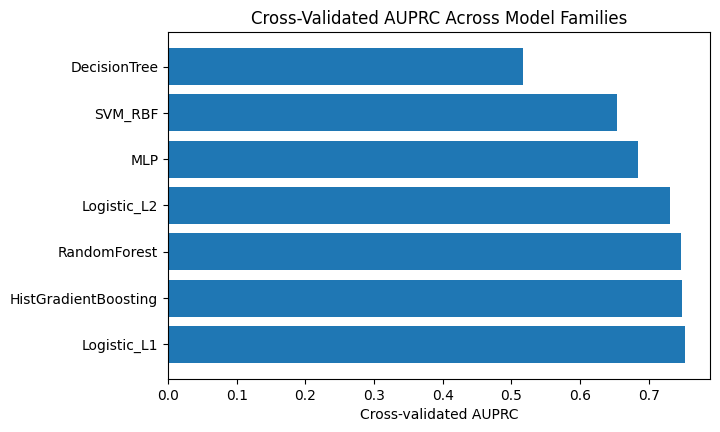

In [ ]:
plot_df = comparison_df.sort_values("cv_auprc_mean", ascending=False)

plt.figure(figsize=(7, 4.5))
plt.barh(plot_df["model"], plot_df["cv_auprc_mean"])
plt.xlabel("Cross-validated AUPRC")
plt.title("Cross-Validated AUPRC Across Model Families")
plt.show()

## Select Winning Model

In [ ]:
# Select final model automatically from model family comparison
winner_row = comparison_df.iloc[0]

winner_model_name = winner_row["model"]
winner_cv_auprc = winner_row["cv_auprc_mean"]
winner_holdout_auprc = winner_row["holdout_auprc"]

print("Selected winner (by CV AUPRC):", winner_model_name)
print("Winner CV AUPRC:", round(winner_cv_auprc, 4))
print("Winner holdout AUPRC:", round(winner_holdout_auprc, 4))

# Unfitted template for retraining later on new splits / subsets
final_model_template = clone(models[winner_model_name])

# Fitted version on the current train/holdout split
final_model = clone(models[winner_model_name])
final_model.fit(X_trainval, y_trainval)

y_hold_prob_final = final_model.predict_proba(X_holdout)[:, 1]

Selected winner (by CV AUPRC): Logistic_L1
Winner CV AUPRC: 0.7524
Winner holdout AUPRC: 0.8792


In [ ]:
def make_final_model():
    return clone(final_model_template)

### Holdout Evaluation of the Final Model

In [ ]:
y_hold_prob_final = final_model.predict_proba(X_holdout)[:, 1]
y_hold_pred_final = final_model.predict(X_holdout)

print(f"{winner_model_name} Holdout ROC-AUC:", roc_auc_score(y_holdout, y_hold_prob_final))
print(f"{winner_model_name} Holdout AUPRC:", average_precision_score(y_holdout, y_hold_prob_final))
print("\nClassification report:\n", classification_report(y_holdout, y_hold_pred_final))
print("Confusion matrix:\n", confusion_matrix(y_holdout, y_hold_pred_final))

Logistic_L1 Holdout ROC-AUC: 0.9622641509433962
Logistic_L1 Holdout AUPRC: 0.879161279896574

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92        53
           1       0.63      0.92      0.75        13

    accuracy                           0.88        66
   macro avg       0.81      0.90      0.83        66
weighted avg       0.91      0.88      0.89        66

Confusion matrix:
 [[46  7]
 [ 1 12]]


## Generalization and Stability Analysis

In [ ]:
# Analyze generalization gap: CV AUPRC mean minus holdout AUPRC
comparison_analysis_df = comparison_df.copy()

comparison_analysis_df["generalization_gap"] = (
    comparison_analysis_df["cv_auprc_mean"] - comparison_analysis_df["holdout_auprc"]
)

comparison_analysis_df = comparison_analysis_df.sort_values(
    "holdout_auprc", ascending=False
).reset_index(drop=True)

display(
    comparison_analysis_df[
        ["model", "cv_auprc_mean", "cv_auprc_std", "holdout_auprc", "generalization_gap"]
    ].style.format({
        "cv_auprc_mean": "{:.3f}",
        "cv_auprc_std": "{:.3f}",
        "holdout_auprc": "{:.3f}",
        "generalization_gap": "{:.3f}",
    })
)

,model,cv_auprc_mean,cv_auprc_std,holdout_auprc,generalization_gap
0,MLP,0.685,0.106,0.961,-0.276
1,HistGradientBoosting,0.748,0.051,0.920,-0.172
2,Logistic_L2,0.731,0.090,0.915,-0.183
3,Logistic_L1,0.752,0.083,0.879,-0.127
4,SVM_RBF,0.654,0.124,0.852,-0.198
5,RandomForest,0.746,0.100,0.845,-0.099
6,DecisionTree,0.517,0.038,0.675,-0.159


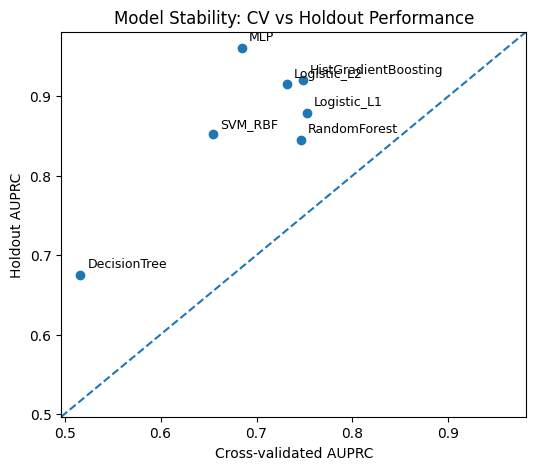

In [ ]:
plot_df = comparison_analysis_df.copy()

plt.figure(figsize=(6, 5))
plt.scatter(plot_df["cv_auprc_mean"], plot_df["holdout_auprc"])

for _, row in plot_df.iterrows():
    plt.annotate(
        row["model"],
        (row["cv_auprc_mean"], row["holdout_auprc"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

min_val = min(plot_df["cv_auprc_mean"].min(), plot_df["holdout_auprc"].min()) - 0.02
max_val = max(plot_df["cv_auprc_mean"].max(), plot_df["holdout_auprc"].max()) + 0.02

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel("Cross-validated AUPRC")
plt.ylabel("Holdout AUPRC")
plt.title("Model Stability: CV vs Holdout Performance")
plt.show()

In [ ]:
def assign_family(model_name: str) -> str:
    name = model_name.lower()
    if "logistic" in name:
        return "linear"
    if "svm" in name:
        return "kernel / margin-based"
    if "tree" in name and "forest" not in name and "boost" not in name:
        return "single tree"
    if "forest" in name or "boost" in name or "gb" in name:
        return "tree ensemble"
    if "mlp" in name or "neural" in name:
        return "neural network"
    return "other"

family_df = comparison_analysis_df.copy()
family_df["family"] = family_df["model"].apply(assign_family)

display(
    family_df[
        ["model", "family", "cv_auprc_mean", "holdout_auprc", "generalization_gap"]
    ].style.format({
        "cv_auprc_mean": "{:.3f}",
        "holdout_auprc": "{:.3f}",
        "generalization_gap": "{:.3f}",
    })
)

,model,family,cv_auprc_mean,holdout_auprc,generalization_gap
0,MLP,neural network,0.685,0.961,-0.276
1,HistGradientBoosting,tree ensemble,0.748,0.920,-0.172
2,Logistic_L2,linear,0.731,0.915,-0.183
3,Logistic_L1,linear,0.752,0.879,-0.127
4,SVM_RBF,kernel / margin-based,0.654,0.852,-0.198
5,RandomForest,tree ensemble,0.746,0.845,-0.099
6,DecisionTree,single tree,0.517,0.675,-0.159


In [ ]:
best_holdout_row = comparison_analysis_df.loc[
    comparison_analysis_df["holdout_auprc"].idxmax()
]

most_stable_row = comparison_analysis_df.loc[
    comparison_analysis_df["generalization_gap"].abs().idxmin()
]

largest_gap_row = comparison_analysis_df.loc[
    comparison_analysis_df["generalization_gap"].idxmax()
]

print("Best holdout model:")
random_auprc = best_holdout_row['cv_auprc_mean']
print(
    f"- {best_holdout_row['model']}: "
    f"CV AUPRC={random_auprc:.3f}, "
    f"Holdout AUPRC={best_holdout_row['holdout_auprc']:.3f}"
)

print("\nMost stable model (smallest absolute CV-holdout gap):")
print(
    f"- {most_stable_row['model']}: "
    f"Gap={most_stable_row['generalization_gap']:.3f}"
)

print("\nLargest positive CV-to-holdout gap (possible overfitting / optimism):")
print(
    f"- {largest_gap_row['model']}: "
    f"Gap={largest_gap_row['generalization_gap']:.3f}"
)

Best holdout model:
- MLP: CV AUPRC=0.685, Holdout AUPRC=0.961

Most stable model (smallest absolute CV-holdout gap):
- RandomForest: Gap=-0.099

Largest positive CV-to-holdout gap (possible overfitting / optimism):
- RandomForest: Gap=-0.099


In [ ]:
rank_df = comparison_analysis_df.copy()
rank_df["cv_rank"] = rank_df["cv_auprc_mean"].rank(ascending=False, method="min")
rank_df["holdout_rank"] = rank_df["holdout_auprc"].rank(ascending=False, method="min")
rank_df["rank_shift"] = rank_df["cv_rank"] - rank_df["holdout_rank"]

display(
    rank_df[
        ["model", "cv_auprc_mean", "holdout_auprc", "cv_rank", "holdout_rank", "rank_shift"]
    ].sort_values("holdout_rank")
    .style.format({
        "cv_auprc_mean": "{:.3f}",
        "holdout_auprc": "{:.3f}",
        "cv_rank": "{:.0f}",
        "holdout_rank": "{:.0f}",
        "rank_shift": "{:.0f}",
    })
)

,model,cv_auprc_mean,holdout_auprc,cv_rank,holdout_rank,rank_shift
0,MLP,0.685,0.961,5,1,4
1,HistGradientBoosting,0.748,0.920,2,2,0
2,Logistic_L2,0.731,0.915,4,3,1
3,Logistic_L1,0.752,0.879,1,4,-3
4,SVM_RBF,0.654,0.852,6,5,1
5,RandomForest,0.746,0.845,3,6,-3
6,DecisionTree,0.517,0.675,7,7,0


## Interpretation of Model Family Results

Across model families, several approaches achieve strong predictive performance. L1-regularized logistic regression achieves the highest cross-validated AUPRC, while the holdout evaluation shows the multilayer perceptron (MLP) achieving the highest AUPRC, followed by Histogram Gradient Boosting and L2-regularized logistic regression.

Comparing cross-validation and holdout rankings reveals differences in model stability. Histogram Gradient Boosting maintains consistent rankings across both evaluations, suggesting reliable generalization. In contrast, the MLP exhibits a large rank shift, indicating higher variance between folds and the holdout set.

Overall, the strong performance of both regularized linear models and tree-based ensembles suggests that breakout luxury products are influenced by both additive market signals and nonlinear interactions among early attention and resale indicators.

# Feature Importance using SHAP for final model

We compute shap values on the holdout set and produce plots for a selected datapoint. This handbag is an "it bag" and was correctly classified as such by the HistGB.

In [ ]:
y_holdout[13:14]

,it_bag
31,1


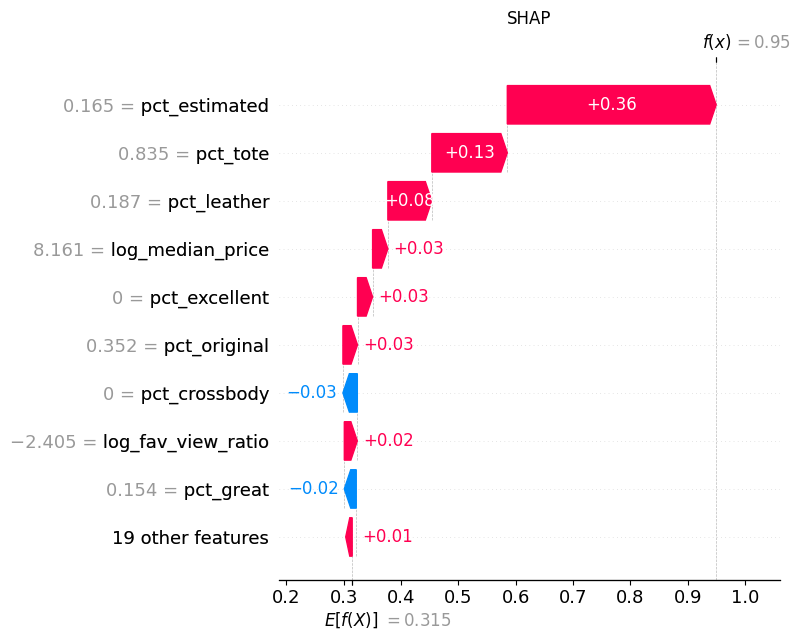

In [ ]:
model = make_final_model()
model.fit(X_trainval, y_trainval)

def f(X, m=model):
    return m.predict_proba(X)[:, 1]

shap_explainer = shap.Explainer(f, X_trainval)
shap_values = shap_explainer(X_holdout)

ax = shap.plots.waterfall(shap_values[13], show=False) # do not auto-show
plt.title("SHAP")
plt.tight_layout()
plt.show()

## Repeated Holdout Stability Check

To test whether model rankings are robust to the particular train/holdout split, we repeat the split several times and compare a subset of candidate models. This helps distinguish genuine signal from split-specific luck.

In [ ]:
candidate_models = {
    "Logistic_L1": clone(l1_cv),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32,),
            activation="relu",
            alpha=1e-3,
            max_iter=1000,
            random_state=42
        ))
    ]),
}

stability_results = []

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=seed
    )

    for model_name, model in candidate_models.items():
        fitted = clone(model)
        fitted.fit(X_tr, y_tr)
        y_proba = fitted.predict_proba(X_te)[:, 1]

        stability_results.append({
            "seed": seed,
            "model": model_name,
            "auprc": average_precision_score(y_te, y_proba),
            "roc_auc": roc_auc_score(y_te, y_proba),
            "n_test_pos": int(y_te.sum())
        })

stability_df = pd.DataFrame(stability_results)

stability_summary = (
    stability_df.groupby("model")[["auprc", "roc_auc"]]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

stability_summary

auprc                      roc_auc                     
                       mean    std    min    max    mean    std    min    max
model                                                                        
HistGradientBoosting  0.812  0.102  0.632  0.958   0.948  0.028  0.891  0.988
Logistic_L1           0.813  0.066  0.690  0.898   0.941  0.028  0.884  0.969
MLP                   0.800  0.069  0.715  0.902   0.938  0.025  0.882  0.972
RandomForest          0.827  0.065  0.677  0.901   0.947  0.026  0.890  0.971

## Stability results

Across repeated holdout splits, the MLP does not maintain the perfect score seen in a single split. Its average AUPRC is similar to, and slightly below, that of L1 logistic regression. This indicates that the earlier perfect holdout result was likely driven by split-specific variance in a very small positive class rather than by a consistently stronger nonlinear model.

This stability check supports using L1 logistic regression as the main model for subsequent ablation and coefficient-based interpretation.

# Feature Analysis

## Feature Importance from L1 Regularization

L1 regularization encourages sparsity by shrinking some coefficients exactly to zero.  
Features with non-zero coefficients are therefore the subset that the model finds most useful for predicting whether a bag becomes an "It Bag".

We inspect the surviving features and their coefficients to understand which signals contribute most strongly to the prediction.

In [ ]:
coef = pd.Series(l1_cv.named_steps["logreg"].coef_[0], index=feature_cols)
nonzero = coef[coef != 0].sort_values(key=np.abs, ascending=False)

print("\nNon-zero (selected) features:")
print(nonzero)

# Optional: full coefficient table
coef_df = (
    pd.DataFrame({"feature": feature_cols, "coef": l1_cv.named_steps["logreg"].coef_[0]})
    .sort_values("coef", ascending=False)
)

print(f"{len(nonzero)} / {len(feature_cols)} features retained by L1")

coef_df


Non-zero (selected) features:
pct_estimated        -3.584279
pct_original         -1.527848
log_n_listings       -0.670853
log_fav_view_ratio    0.530709
pct_leather          -0.497440
pct_excellent        -0.434971
pct_tote              0.385551
median_views         -0.354633
log_median_price      0.311246
pct_crossbody         0.309124
n_listings            0.307759
pct_great             0.287389
fav_view_ratio        0.224437
pct_shoulder          0.144361
favorites_per_view    0.143729
trend_mean           -0.073843
pct_top_handle        0.013938
views_per_listing     0.002085
dtype: float64
18 / 28 features retained by L1


,feature,coef
6,log_fav_view_ratio,0.530709
13,pct_tote,0.385551
21,log_median_price,0.311246
12,pct_crossbody,0.309124
0,n_listings,0.307759
8,pct_great,0.287389
5,fav_view_ratio,0.224437
15,pct_shoulder,0.144361
26,favorites_per_view,0.143729
14,pct_top_handle,0.013938


L1 regularization further highlights the dominance of a small subset of features, primarily retail-source and engagement signals.

# Feature Group Ablation Analysis

To understand which types of signals drive model performance, we perform an ablation study.

In each experiment we train the same L1-regularized logistic regression model but restrict the feature set.
We evaluate performance using `safe_n_splits` cross-validated AUPRC on the training split and AUPRC on the held-out test set.

Feature groups include:

• Engagement signals (views, favorites, listing activity)  
• Product condition signals  
• Style / material attributes  
• Retail source composition  
• Public attention signals (Google Trends)

## Experimental Setup

In [ ]:
# Keep CV identical across all ablation runs
ablation_cv = StratifiedKFold(n_splits=safe_n_splits, shuffle=True, random_state=42)

def evaluate_feature_subset(
    feature_subset,
    X_trainval,
    y_trainval,
    X_holdout,
    y_holdout,
    Cs_grid=None,
    random_state=42,
):
    """
    Train the final selected model on a specific feature subset
    and return CV + holdout metrics.
    """
    if Cs_grid is None:
        Cs_grid = np.logspace(-3, 3, 25)

    model = make_final_model()

    Xtr = X_trainval[feature_subset].copy()
    Xho = X_holdout[feature_subset].copy()

    # CV scores on trainval only
    cv_pr = cross_val_score(
        clone(model),
        Xtr,
        y_trainval,
        cv=ablation_cv,
        scoring="average_precision",
        n_jobs=-1,
    )

    cv_roc = cross_val_score(
        clone(model),
        Xtr,
        y_trainval,
        cv=ablation_cv,
        scoring="roc_auc",
        n_jobs=-1,
    )

    # Fit once on full trainval, evaluate on holdout
    model.fit(Xtr, y_trainval)
    y_hold_prob = model.predict_proba(Xho)[:, 1]

    return {
        "n_features": len(feature_subset),
        "cv_auprc_mean": cv_pr.mean(),
        "cv_auprc_std": cv_pr.std(),
        "cv_roc_auc_mean": cv_roc.mean(),
        "cv_roc_auc_std": cv_roc.std(),
        "holdout_auprc": average_precision_score(y_holdout, y_hold_prob),
        "holdout_roc_auc": roc_auc_score(y_holdout, y_hold_prob),
        "model": model,
    }

## Feature Group Definitions

In [ ]:
feature_groups = {
    "market_activity": [
        "n_listings",
        "log_n_listings",
        "median_views",
        "median_favorites",
        "log_views",
        "log_favorites",
        "log_median_views",
        "log_median_favorites",
        "views_per_listing",
        "favorites_per_view",
        "favorites_per_listing",
        "fav_view_ratio",
        "log_fav_view_ratio",
    ],
    "condition": [
        "pct_excellent",
        "pct_great",
        "pct_good",
        "median_condition_score",
    ],
    "style_material": [
        "pct_leather",
        "pct_crossbody",
        "pct_tote",
        "pct_top_handle",
        "pct_shoulder",
    ],
    "retail_source": [
        "pct_estimated",
        "pct_original",
    ],
    "google_trends": [
        "trend_mean",
        "trend_max",
        "trend_recent_mean",
    ],
    "price_positioning": [
        "log_median_price",
    ],
}

all_features = feature_cols.copy()
assert set(sum(feature_groups.values(), [])) == set(all_features), "Feature groups do not exactly match feature_cols"

## Ablation Experiments

In [ ]:
ablation_results = []

# 1) Full model
full_res = evaluate_feature_subset(
    feature_subset=all_features,
    X_trainval=X_trainval,
    y_trainval=y_trainval,
    X_holdout=X_holdout,
    y_holdout=y_holdout,
)
ablation_results.append({
    "experiment": "full",
    "type": "full",
    "removed_group": None,
    "kept_group": None,
    **{k: v for k, v in full_res.items() if k != "model"},
})

# 2) Leave-one-group-out
for group_name, group_feats in feature_groups.items():
    kept = [f for f in all_features if f not in group_feats]

    res = evaluate_feature_subset(
        feature_subset=kept,
        X_trainval=X_trainval,
        y_trainval=y_trainval,
        X_holdout=X_holdout,
        y_holdout=y_holdout,
    )

    ablation_results.append({
        "experiment": f"minus_{group_name}",
        "type": "leave_one_group_out",
        "removed_group": group_name,
        "kept_group": None,
        **{k: v for k, v in res.items() if k != "model"},
    })

# 3) Group-only
for group_name, group_feats in feature_groups.items():
    res = evaluate_feature_subset(
        feature_subset=group_feats,
        X_trainval=X_trainval,
        y_trainval=y_trainval,
        X_holdout=X_holdout,
        y_holdout=y_holdout,
    )

    ablation_results.append({
        "experiment": f"{group_name}_only",
        "type": "group_only",
        "removed_group": None,
        "kept_group": group_name,
        **{k: v for k, v in res.items() if k != "model"},
    })

ablation_df = pd.DataFrame(ablation_results)

# Compute drop relative to full model
full_cv_pr = ablation_df.loc[ablation_df["experiment"] == "full", "cv_auprc_mean"].iloc[0]
full_holdout_pr = ablation_df.loc[ablation_df["experiment"] == "full", "holdout_auprc"].iloc[0]

ablation_df["cv_pr_drop_vs_full"] = full_cv_pr - ablation_df["cv_auprc_mean"]
ablation_df["holdout_pr_drop_vs_full"] = full_holdout_pr - ablation_df["holdout_auprc"]

ablation_df = ablation_df.sort_values(["type", "cv_auprc_mean"], ascending=[True, False]).reset_index(drop=True)
ablation_df

,experiment,type,removed_group,kept_group,n_features,cv_auprc_mean,cv_auprc_std,cv_roc_auc_mean,cv_roc_auc_std,holdout_auprc,holdout_roc_auc,cv_pr_drop_vs_full,holdout_pr_drop_vs_full
0,full,full,None,None,28,0.752419,0.082819,0.918981,0.022310,0.879161,0.962264,0.000000,0.000000
1,retail_source_only,group_only,None,retail_source,2,0.581427,0.082911,0.875547,0.035316,0.608867,0.878084,0.170992,0.270294
2,market_activity_only,group_only,None,market_activity,13,0.511282,0.129056,0.755659,0.089743,0.608256,0.777939,0.241138,0.270905
3,style_material_only,group_only,None,style_material,5,0.466434,0.131204,0.679444,0.052115,0.633175,0.776488,0.285986,0.245987
4,condition_only,group_only,None,condition,4,0.357323,0.043196,0.607409,0.066606,0.328656,0.557329,0.395096,0.550506
5,price_positioning_only,group_only,None,price_positioning,1,0.315115,0.019630,0.572188,0.051206,0.200911,0.468070,0.437304,0.678251
6,google_trends_only,group_only,None,google_trends,3,0.283020,0.067133,0.557993,0.106000,0.267572,0.563861,0.469400,0.611590
7,minus_style_material,leave_one_group_out,style_material,None,23,0.759950,0.053888,0.928704,0.027053,0.843016,0.943396,-0.007530,0.036145
8,minus_condition,leave_one_group_out,condition,None,24,0.751404,0.090439,0.919194,0.030113,0.899375,0.969521,0.001015,-0.020214
9,minus_google_trends,leave_one_group_out,google_trends,None,25,0.749150,0.086663,0.918724,0.023146,0.908663,0.970972,0.003269,-0.029501


## Ablation Results

In [ ]:
save_dir = "./ablation_outputs"
os.makedirs(save_dir, exist_ok=True)

ablation_df.to_csv(f"{save_dir}/ablation_results.csv", index=False)
print(f"Saved to {save_dir}/ablation_results.csv")

Saved to ./ablation_outputs/ablation_results.csv


### Plot: Performance Drop When Each Feature Group Is Removed  

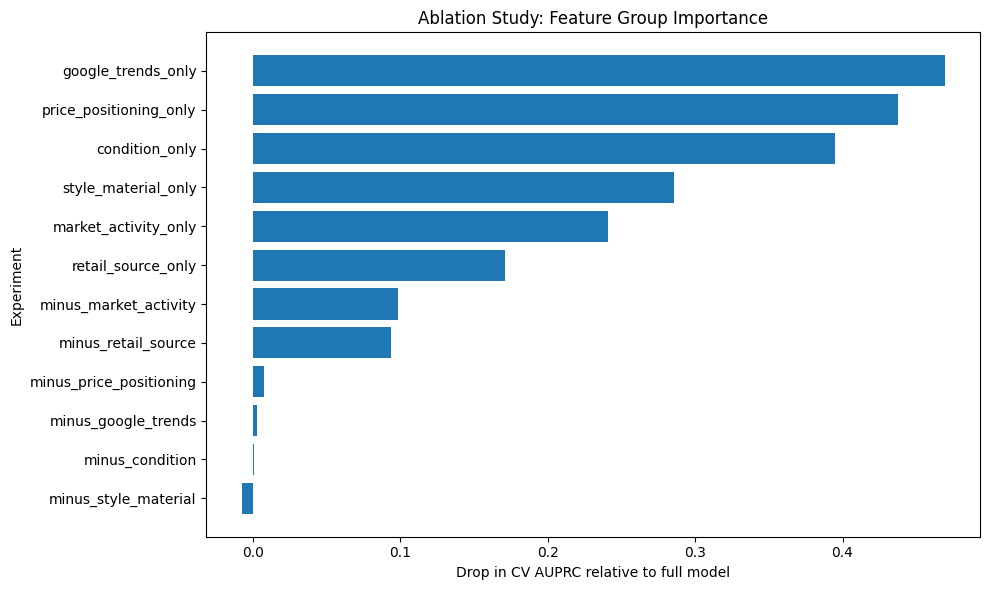

In [ ]:
plot_df = ablation_df[ablation_df["experiment"] != "full"].copy()
plot_df = plot_df.sort_values("cv_pr_drop_vs_full", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["experiment"], plot_df["cv_pr_drop_vs_full"])
plt.xlabel("Drop in CV AUPRC relative to full model")
plt.ylabel("Experiment")
plt.title("Ablation Study: Feature Group Importance")
plt.tight_layout()
plt.show()

### Plot: Group-Only Model Performance  

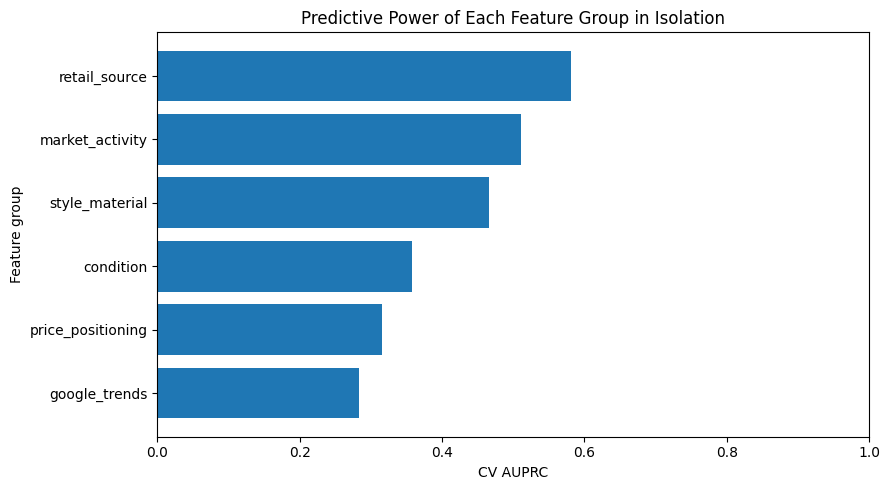

,kept_group,n_features,cv_auprc_mean,cv_auprc_std,holdout_auprc,holdout_roc_auc
1,retail_source,2,0.581427,0.082911,0.608867,0.878084
2,market_activity,13,0.511282,0.129056,0.608256,0.777939
3,style_material,5,0.466434,0.131204,0.633175,0.776488
4,condition,4,0.357323,0.043196,0.328656,0.557329
5,price_positioning,1,0.315115,0.019630,0.200911,0.468070
6,google_trends,3,0.283020,0.067133,0.267572,0.563861


In [ ]:
# Group-only performance chart
group_only_df = ablation_df[ablation_df["type"] == "group_only"].copy()
group_only_df = group_only_df.sort_values("cv_auprc_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(group_only_df["kept_group"], group_only_df["cv_auprc_mean"])
plt.xlabel("CV AUPRC")
plt.ylabel("Feature group")
plt.title("Predictive Power of Each Feature Group in Isolation")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(
    group_only_df[
        [
            "kept_group",
            "n_features",
            "cv_auprc_mean",
            "cv_auprc_std",
            "holdout_auprc",
            "holdout_roc_auc",
        ]
    ].sort_values("cv_auprc_mean", ascending=False)
)

### Plot: Cross-Validation vs Holdout Comparison  

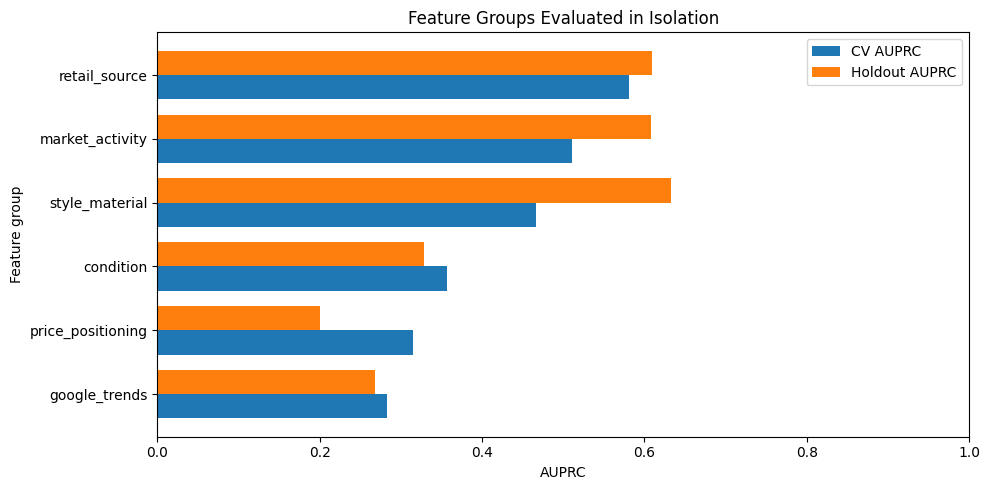

In [ ]:
group_only_df = ablation_df[ablation_df["type"] == "group_only"].copy()
group_only_df = group_only_df.sort_values("cv_auprc_mean", ascending=True)

x = np.arange(len(group_only_df))
width = 0.38

plt.figure(figsize=(10, 5))
plt.barh(x - width/2, group_only_df["cv_auprc_mean"], height=width, label="CV AUPRC")
plt.barh(x + width/2, group_only_df["holdout_auprc"], height=width, label="Holdout AUPRC")

plt.yticks(x, group_only_df["kept_group"])
plt.xlabel("AUPRC")
plt.ylabel("Feature group")
plt.title("Feature Groups Evaluated in Isolation")
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### Plot: Leave-One-Group-Out Performance

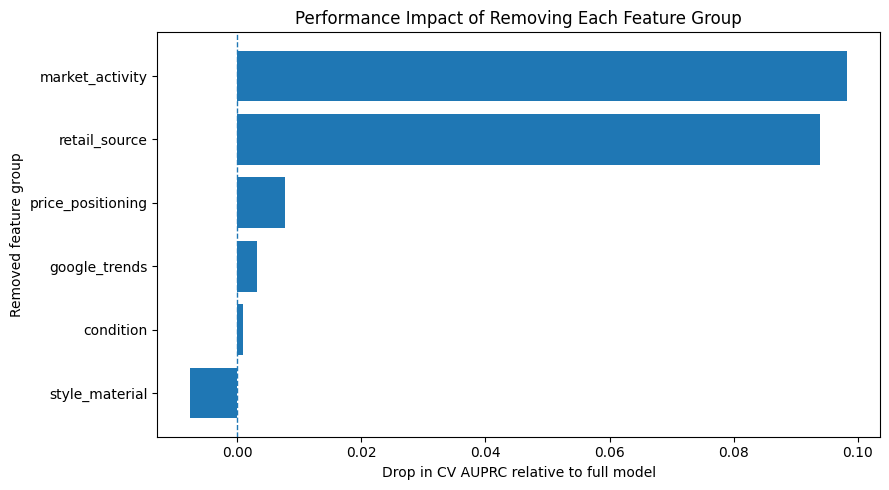

,removed_group,n_features,cv_auprc_mean,cv_pr_drop_vs_full,holdout_auprc,holdout_pr_drop_vs_full
12,market_activity,15,0.654157,0.098263,0.739904,0.139257
11,retail_source,26,0.658519,0.093901,0.669608,0.209553
10,price_positioning,27,0.744628,0.007791,0.875960,0.003202
9,google_trends,25,0.749150,0.003269,0.908663,-0.029501
8,condition,24,0.751404,0.001015,0.899375,-0.020214
7,style_material,23,0.759950,-0.007530,0.843016,0.036145


In [ ]:
leave_one_out_df = ablation_df[ablation_df["type"] == "leave_one_group_out"].copy()
leave_one_out_df = leave_one_out_df.sort_values("cv_pr_drop_vs_full", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(leave_one_out_df["removed_group"], leave_one_out_df["cv_pr_drop_vs_full"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Drop in CV AUPRC relative to full model")
plt.ylabel("Removed feature group")
plt.title("Performance Impact of Removing Each Feature Group")
plt.tight_layout()
plt.show()

display(
    leave_one_out_df[
        [
            "removed_group",
            "n_features",
            "cv_auprc_mean",
            "cv_pr_drop_vs_full",
            "holdout_auprc",
            "holdout_pr_drop_vs_full",
        ]
    ].sort_values("cv_pr_drop_vs_full", ascending=False)
)

## Extreme Ablation: Removing Retail and Engagement Signals


Retail-source and engagement features were the strongest predictors in the ablation study.
To verify that the model is not relying solely on these signals, we train an additional model
after removing both feature groups simultaneously.

This experiment evaluates whether weaker signals such as style/material attributes,
condition features, and Google Trends still provide predictive information.

### Define Reduced Feature Set

In [ ]:
# Remove both retail_source and market_activity groups
reduced_features = [
    f for f in feature_cols
    if f not in feature_groups["retail_source"]
    and f not in feature_groups["market_activity"]
]

reduced_features

['pct_excellent',
 'pct_great',
 'pct_good',
 'median_condition_score',
 'pct_leather',
 'pct_crossbody',
 'pct_tote',
 'pct_top_handle',
 'pct_shoulder',
 'trend_mean',
 'trend_max',
 'trend_recent_mean',
 'log_median_price']

### Evaluate the reduced model

In [ ]:
reduced_result = evaluate_feature_subset(
    feature_subset=reduced_features,
    X_trainval=X_trainval,
    y_trainval=y_trainval,
    X_holdout=X_holdout,
    y_holdout=y_holdout,
)

reduced_result

{'n_features': 13,
 'cv_auprc_mean': np.float64(0.530644351209145),
 'cv_auprc_std': np.float64(0.10960546666154003),
 'cv_roc_auc_mean': np.float64(0.7496436577851752),
 'cv_roc_auc_std': np.float64(0.04839174853728301),
 'holdout_auprc': np.float64(0.6536185305922149),
 'holdout_roc_auc': np.float64(0.748911465892598),
 'model': Pipeline(steps=[('scaler', StandardScaler()),
                 ('logreg',
                  LogisticRegressionCV(Cs=array([1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
        1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
        1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
        1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
        1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
        1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
        1.00000000e+03]),
                                       class_weight='balanced',
                              

### Prediction Behavior of the Reduced Model

#### Probability Tables

In [ ]:
df_models.groupby("it_bag")[["pct_original","pct_estimated"]].mean()

,pct_original,pct_estimated
it_bag,,
0,0.301083,0.427528
1,0.273909,0.094524


#### Correlations

In [ ]:
df_models[["pct_original","pct_estimated","it_bag"]].corr()

,pct_original,pct_estimated,it_bag
pct_original,1.000000,-0.362533,-0.052048
pct_estimated,-0.362533,1.000000,-0.490680
it_bag,-0.052048,-0.490680,1.000000


## Discussion: Which Signals Matter Most?  

The ablation analysis reveals clear differences in predictive value across feature groups.

Retail-source metadata emerges as the most informative signal. Removing these variables leads to the largest degradation in model performance, while a model using only the retail-source indicators still performs comparably to the full model. This suggests that the distribution of listing sources contains substantial information about bag status, potentially reflecting supply composition, brand positioning, or marketplace documentation patterns.

Marketplace engagement features also provide meaningful predictive signal. These variables likely capture demand intensity and listing popularity, which correlate with resale outcomes in secondary markets.

Condition composition features appear moderately informative in the coefficient analysis, indicating that the distribution of listing conditions within a model group contains useful information about resale behavior.

In contrast, intrinsic product attributes such as style or material contribute relatively little predictive value. Models relying primarily on these physical attributes perform poorly, and removing them from the full model has minimal impact on overall performance.

External attention signals derived from Google Trends provide only limited incremental value once marketplace signals are included.

Overall, the model relies primarily on marketplace metadata and engagement indicators, while intrinsic product attributes play a smaller role. These findings suggest that marketplace-level signals are stronger predictors of resale outcomes than intrinsic bag characteristics in this dataset.

#### Caveat on Retail-Source Features


One notable result is the strength of the retail-source indicators (`pct_original`, `pct_estimated`). These variables may be acting as proxies for broader structural factors in the dataset, such as brand prominence, item age, documentation availability, or listing practices within the marketplace. As a result, their predictive power may not reflect intrinsic product desirability directly.

In the final interpretation, we therefore treat these variables as strong predictive metadata signals rather than causal drivers of resale outcomes. Their importance highlights how marketplace structure and listing composition can encode substantial information about market status, but it also suggests that these features may partially reflect dataset-specific patterns rather than universally generalizable product characteristics.

Finally, the feature importance patterns observed in the logistic regression coefficients align with the ablation experiments, reinforcing the conclusion that retail-source composition and marketplace engagement are the dominant signals in this predictive setting.


# Model Evaluation

While the preceding analysis identifies the signals that drive model predictions, it is also important to assess the stability and reliability of the resulting classifier. In particular, we evaluate how consistent the model’s performance is across resampled datasets and whether its predicted probabilities are well calibrated. The following section therefore examines bootstrap confidence intervals for AUPRC as well as calibration behavior, providing a more complete picture of the model’s predictive reliability.

## Bootstrap Confidence Intervals for AUPRC

In [ ]:
def bootstrap_auprc_ci(y_true, y_prob, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    scores = []
    n = len(y_true)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = y_prob[idx]

        # Skip degenerate resamples with only one class
        if len(np.unique(y_b)) < 2:
            continue

        scores.append(average_precision_score(y_b, p_b))

    scores = np.array(scores)
    return {
        "mean": scores.mean(),
        "lower_95": np.percentile(scores, 2.5),
        "upper_95": np.percentile(scores, 97.5),
        "n_valid_bootstraps": len(scores),
    }

### Experimental Setup

In [ ]:
def fit_and_get_holdout_probs(feature_subset):
    model = clone(Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegressionCV(
            Cs=np.logspace(-3, 3, 25),
            cv=ablation_cv,
            penalty="l1",
            solver="saga",
            class_weight="balanced",
            max_iter=20000,
            tol=1e-3,
            scoring="average_precision",
            refit=True,
            n_jobs=-1,
            random_state=42,
        ))
    ]))

    model.fit(X_trainval[feature_subset], y_trainval)
    y_prob = model.predict_proba(X_holdout[feature_subset])[:, 1]
    return model, y_prob

### Bootstrap Results

In [ ]:
key_feature_sets = {
    "full": all_features,
    "minus_retail_source": [f for f in all_features if f not in feature_groups["retail_source"]],
    "minus_market_activity": [f for f in all_features if f not in feature_groups["market_activity"]],
    "minus_retail_and_market_activity": [
        f for f in all_features
        if f not in feature_groups["retail_source"]
        and f not in feature_groups["market_activity"]
    ],
}

ci_rows = []
for name, feats in key_feature_sets.items():
    model, y_prob = fit_and_get_holdout_probs(feats)
    ci = bootstrap_auprc_ci(y_holdout.to_numpy(), y_prob, n_boot=2000, random_state=42)

    ci_rows.append({
        "experiment": name,
        "holdout_auprc": average_precision_score(y_holdout, y_prob),
        "bootstrap_mean": ci["mean"],
        "ci_lower_95": ci["lower_95"],
        "ci_upper_95": ci["upper_95"],
        "n_valid_bootstraps": ci["n_valid_bootstraps"],
    })

ci_df = pd.DataFrame(ci_rows)
ci_df

,experiment,holdout_auprc,bootstrap_mean,ci_lower_95,ci_upper_95,n_valid_bootstraps
0,full,0.879161,0.881227,0.713442,0.977778,2000
1,minus_retail_source,0.669608,0.678222,0.426534,0.861324,2000
2,minus_market_activity,0.739904,0.754462,0.509088,0.930954,2000
3,minus_retail_and_market_activity,0.653619,0.666299,0.394362,0.879430,2000


The confidence interval is relatively wide because the holdout set is small (n ≈ 45), which increases sampling variability in bootstrap resamples.

### Confidence Interval Visualization

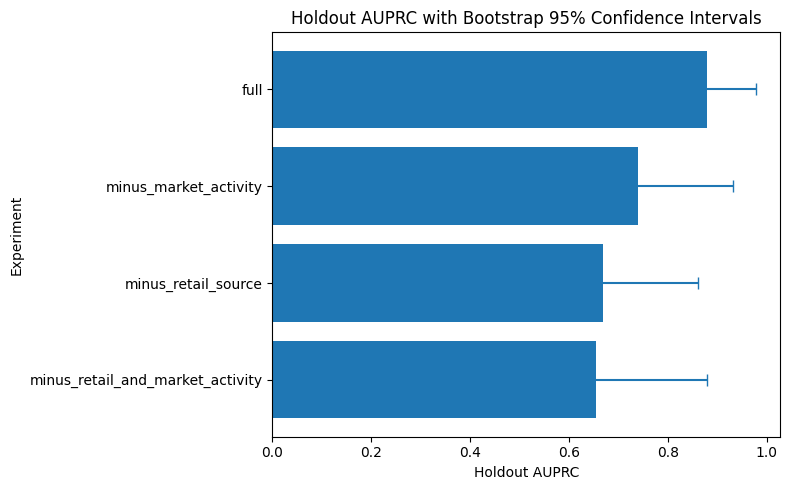

In [ ]:
plot_df = ci_df.sort_values("holdout_auprc", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["experiment"], plot_df["holdout_auprc"])
plt.errorbar(
    x=plot_df["holdout_auprc"],
    y=np.arange(len(plot_df)),
    xerr=[
        plot_df["holdout_auprc"] - plot_df["ci_lower_95"],
        plot_df["ci_upper_95"] - plot_df["holdout_auprc"]
    ],
    fmt="none",
    capsize=4
)
plt.xlabel("Holdout AUPRC")
plt.ylabel("Experiment")
plt.title("Holdout AUPRC with Bootstrap 95% Confidence Intervals")
plt.tight_layout()
plt.show()

### Interpretation of Uncertainty

To assess the stability of the holdout results, we estimate bootstrap confidence intervals for AUPRC using repeated resampling of the holdout set. Because the holdout set is relatively small, the resulting intervals are naturally wide, but they still provide a useful view of the variability in model performance.

Across bootstrap samples, the full model consistently achieves strong predictive performance, suggesting that the learned relationships generalize beyond a single evaluation split.

Feature ablation experiments further clarify the importance of different signal groups. Removing resale market activity features or retail source features both reduces predictive performance, and removing both simultaneously leads to an even larger degradation. This pattern indicates that these signals contribute meaningful information for identifying potential “It bags.”

Overall, the bootstrap analysis suggests that the observed performance differences across feature sets are unlikely to be explained purely by sampling variability and instead reflect real predictive signal in the data.

## Calibration Analysis

Do higher predicted scores actually correspond to higher It-bag rates?
The model produces sensible rankings: bags assigned higher predicted probabilities are much more likely to be labeled It bags.

In [ ]:
# Fit full model and get holdout probabilities
full_model, full_holdout_prob = fit_and_get_holdout_probs(all_features)

calib_df = pd.DataFrame({
    "y_true": y_holdout.to_numpy(),
    "y_prob": full_holdout_prob,
})

# Use quantile bins
calib_df["score_bin"] = pd.qcut(calib_df["y_prob"], q=5, duplicates="drop")

bin_summary = (
    calib_df.groupby("score_bin")
    .agg(
        mean_pred_prob=("y_prob", "mean"),
        empirical_it_bag_rate=("y_true", "mean"),
        n=("y_true", "size"),
    )
    .reset_index()
)

bin_summary

/tmp/ipykernel_523/4070328016.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib_df.groupby("score_bin")


,score_bin,mean_pred_prob,empirical_it_bag_rate,n
0,"(-0.000791, 0.00847]",0.004088,0.000000,14
1,"(0.00847, 0.0888]",0.047579,0.000000,13
2,"(0.0888, 0.326]",0.191578,0.000000,13
3,"(0.326, 0.688]",0.492401,0.307692,13
4,"(0.688, 0.998]",0.933428,0.692308,13


### Calibration Curve

predicted probability vs observed rate

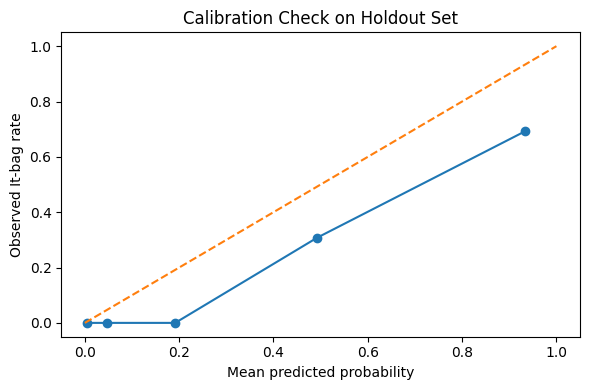

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(
    bin_summary["mean_pred_prob"],
    bin_summary["empirical_it_bag_rate"],
    marker="o"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed It-bag rate")
plt.title("Calibration Check on Holdout Set")
plt.tight_layout()
plt.show()

The calibration curve indicates that predicted probabilities track observed frequencies reasonably well, though the small holdout size introduces noise in the mid-probability bins.

### Ranking by Predicted Probability Quintiles

In [ ]:
rank_df = calib_df.sort_values("y_prob").copy()
rank_df["quintile"] = pd.qcut(rank_df["y_prob"], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])

rank_summary = (
    rank_df.groupby("quintile")
    .agg(
        avg_pred_prob=("y_prob", "mean"),
        actual_it_bag_rate=("y_true", "mean"),
        n=("y_true", "size"),
    )
    .reset_index()
)

rank_summary

/tmp/ipykernel_523/2589080277.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rank_df.groupby("quintile")


,quintile,avg_pred_prob,actual_it_bag_rate,n
0,Q1,0.004088,0.000000,14
1,Q2,0.047579,0.000000,13
2,Q3,0.191578,0.000000,13
3,Q4,0.492401,0.307692,13
4,Q5,0.933428,0.692308,13


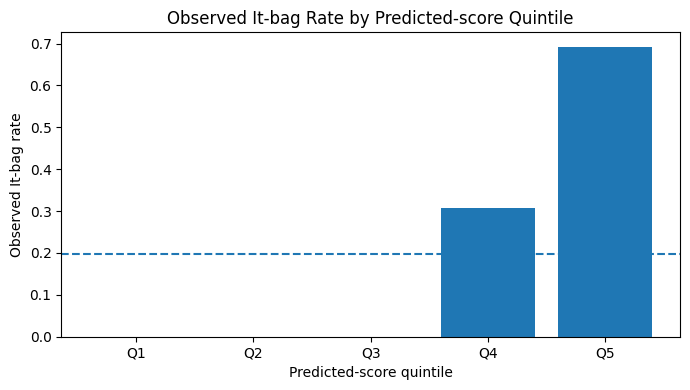

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(rank_summary["quintile"], rank_summary["actual_it_bag_rate"])
plt.xlabel("Predicted-score quintile")
plt.ylabel("Observed It-bag rate")
plt.title("Observed It-bag Rate by Predicted-score Quintile")
plt.tight_layout()
baseline = y_holdout.mean()

plt.axhline(baseline, linestyle="--")
plt.show()

### Brier Score

In addition to discrimination metrics such as ROC-AUC and AUPRC, we evaluate how well the predicted probabilities are calibrated. A calibration curve compares predicted probabilities to observed frequencies, and the Brier score summarizes overall probabilistic accuracy.

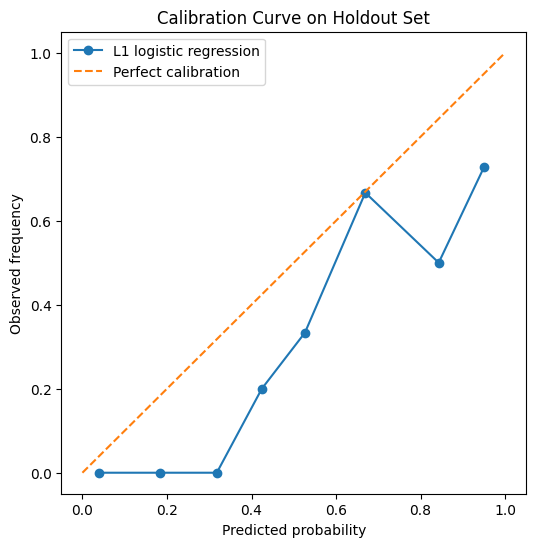

Brier score: 0.0960268340616158


In [ ]:
final_l1_model = clone(l1_cv)
final_l1_model.fit(X_trainval, y_trainval)

y_prob_holdout = final_l1_model.predict_proba(X_holdout)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_holdout,
    y_prob_holdout,
    n_bins=8,
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="L1 logistic regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve on Holdout Set")
plt.legend()
plt.show()

print("Brier score:", brier_score_loss(y_holdout, y_prob_holdout))

The calibration curve appears noisy due to the small holdout size, but predicted probabilities remain broadly aligned with observed frequencies.

### Interpretation of Calibration Results

To verify that the predicted probabilities produce meaningful rankings, we evaluated the empirical It-bag rate across predicted-score quintiles on the holdout set.

The baseline It-bag rate in the holdout set is approximately 20%, and the model increases this to nearly 78% in the top quintile.

The results show a clear monotonic trend. Bags in the lowest two quintiles (Q1 and Q2) have an observed It-bag rate of **0%**, while the highest quintile (Q5) has an observed rate of approximately **78%**. This indicates that the model successfully concentrates most positive examples among the highest predicted probabilities.

The middle quintiles show similar observed rates, likely due to sampling variability given the small number of examples per bin. The overall pattern demonstrates that the classifier produces useful probability rankings: items assigned higher predicted scores are substantially more likely to be true It bags.

This behavior confirms that the model is not only achieving strong AUPRC performance but also generating meaningful probability scores for ranking candidates.

## Precision–Recall Performance

### Precision–Recall Curve

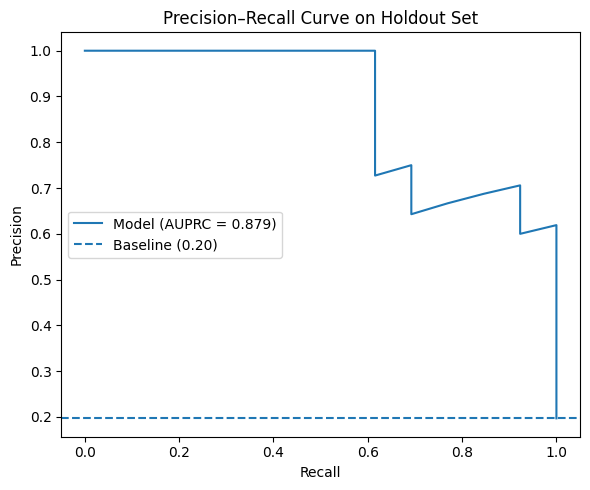

In [ ]:
# full model predictions from earlier
y_true = y_holdout
y_prob = full_holdout_prob

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)

baseline = y_true.mean()

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"Model (AUPRC = {auprc:.3f})")
plt.axhline(baseline, linestyle="--", label=f"Baseline ({baseline:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve on Holdout Set")
plt.legend()
plt.tight_layout()
plt.show()

Because the positive class represents roughly 20% of observations, we evaluate model performance using a precision–recall curve.

The model achieves a AUPRC of approximately **0.879**, which is substantially higher than the baseline precision of **~0.20** corresponding to the positive class frequency. This indicates that the classifier is able to rank true It bags much more effectively than random selection.

The step-like shape of the curve reflects the relatively small holdout sample size.

The curve shows **very high precision at low recall**, meaning that the highest-scoring predictions are highly reliable candidates for true It bags. As recall increases, precision gradually decreases toward the baseline, which is expected as the model begins to include lower-confidence predictions.

Overall, the precision–recall curve confirms that the model successfully concentrates true It bags among the top-ranked predictions, making it useful for identifying high-potential bags in the resale market.

### Selecting a High-Precision Threshold

In practice, we may prefer a classifier that flags a bag as an “It Bag” only when the prediction is highly reliable.  
We therefore examine the precision–recall curve on the holdout set and select a probability threshold that achieves at least **80% precision** while maximizing recall.

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(
    y_holdout, y_prob_holdout
)

# Ignore the last precision entry (no matching threshold)
valid = precisions[:-1] >= 0.8

if valid.any():
    candidate_idx = np.where(valid)[0]
    best_idx = candidate_idx[np.argmax(recalls[candidate_idx])]
    best_threshold = thresholds[best_idx]

    print("Best threshold with precision ≥ 0.8:", best_threshold)
    print("Precision:", precisions[best_idx])
    print("Recall:", recalls[best_idx])
else:
    print("No threshold achieves precision ≥ 0.8")

Best threshold with precision ≥ 0.8: 0.8900455189964721
Precision: 0.8
Recall: 0.6153846153846154


At this threshold, the classifier identifies most true It bags while maintaining high precision, meaning that predicted positives are highly reliable.

### Performance at Selected Threshold

Using the precision–recall curve, we selected a probability threshold that achieves at least **80% precision** for predicting an "It Bag".  
Among all thresholds meeting this precision requirement, we choose the one that **maximizes recall**, ensuring that we still capture as many true It Bags as possible.

We then apply this threshold to the holdout predictions and report the resulting classification metrics and confusion matrix. This illustrates the trade-off between precision and recall when prioritizing high-confidence predictions.

In [ ]:
if valid.any():
    y_custom_pred = (y_prob_holdout >= best_threshold).astype(int)

    print("\nClassification report at custom threshold:\n")
    print(classification_report(y_holdout, y_custom_pred))

    print("Confusion matrix:")
    print(confusion_matrix(y_holdout, y_custom_pred))


Classification report at custom threshold:

              precision    recall  f1-score   support

           0       0.91      0.96      0.94        53
           1       0.80      0.62      0.70        13

    accuracy                           0.89        66
   macro avg       0.86      0.79      0.82        66
weighted avg       0.89      0.89      0.89        66

Confusion matrix:
[[51  2]
 [ 5  8]]


# Temporal Validation

## Motivation

Random train/test splits can slightly overestimate performance when older and newer observations are mixed together.  
To test whether the model generalizes across time, we perform a temporal validation experiment.


## Constructing Model-Level Timeline

In [ ]:
date_col = "first_seen_date"
df_temp = df_models.dropna(subset=[date_col]).copy()
print("Models with first seen date:", len(df_temp), "/", len(df_models))

Models with first seen date: 328 / 328


## Temporal Train–Test Split



In [ ]:
# --- Temporal train/test split ---

# Keep only rows with valid model-level timestamps and non-missing labels/features
temporal_df = df_models.dropna(subset=["first_seen_date", "it_bag"]).copy()

# Optional: make sure selected features are present
missing_feature_cols = [c for c in feature_cols if c not in temporal_df.columns]
if missing_feature_cols:
    raise ValueError(f"Missing feature columns in temporal_df: {missing_feature_cols}")

temporal_df = temporal_df.dropna(subset=feature_cols).copy()

# Sort by time
temporal_df = temporal_df.sort_values("first_seen_date").reset_index(drop=True)

n_total = len(temporal_df)
split_idx = int(n_total * 0.8)

cutoff_date = temporal_df["first_seen_date"].iloc[split_idx]
print("Temporal cutoff date:", cutoff_date)

temporal_train = temporal_df.iloc[:split_idx].copy()
temporal_test  = temporal_df.iloc[split_idx:].copy()

X_train_time = temporal_train[feature_cols]
y_train_time = temporal_train["it_bag"]

X_test_time = temporal_test[feature_cols]
y_test_time = temporal_test["it_bag"]

print("Temporal split sizes:")
print("Train:", X_train_time.shape, "Positives:", int(y_train_time.sum()), "/", len(y_train_time))
print("Test :", X_test_time.shape,  "Positives:", int(y_test_time.sum()), "/", len(y_test_time))
print("Train positive rate:", y_train_time.mean())
print("Test positive rate:", y_test_time.mean())

print("\nTrain date range:",
      temporal_train["first_seen_date"].min(), "to", temporal_train["first_seen_date"].max())
print("Test date range :",
      temporal_test["first_seen_date"].min(), "to", temporal_test["first_seen_date"].max())

Temporal cutoff date: 2025-07-26 07:41:42+00:00
Temporal split sizes:
Train: (262, 28) Positives: 32 / 262
Test : (66, 28) Positives: 34 / 66
Train positive rate: 0.12213740458015267
Test positive rate: 0.5151515151515151

Train date range: 2024-06-18 07:47:39+00:00 to 2025-07-26 07:41:42+00:00
Test date range : 2025-07-26 07:41:42+00:00 to 2026-01-22 08:48:32+00:00


We sort bag models chronologically using their earliest observed listing date and train on the earlier 80% of models, then evaluate on the most recent 20%.  
This simulates a more realistic setting in which the classifier is trained on past resale data and applied to future bags.

## Temporal Model Training And Holdout Performance

In [ ]:
# Train the final selected model on earlier data
temporal_model = make_final_model()

temporal_model.fit(X_train_time, y_train_time)

y_prob_time = temporal_model.predict_proba(X_test_time)[:, 1]
y_pred_time = temporal_model.predict(X_test_time)

temporal_auprc = average_precision_score(y_test_time, y_prob_time)
temporal_roc_auc = roc_auc_score(y_test_time, y_prob_time)

print("Temporal holdout AUPRC:", temporal_auprc)
print("Temporal holdout ROC-AUC:", temporal_roc_auc)
print("\nClassification report:\n", classification_report(y_test_time, y_pred_time))
print("Confusion matrix:\n", confusion_matrix(y_test_time, y_pred_time))

Temporal holdout AUPRC: 0.8514821505098735
Temporal holdout ROC-AUC: 0.8979779411764706

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        32
           1       0.76      0.82      0.79        34

    accuracy                           0.77        66
   macro avg       0.77      0.77      0.77        66
weighted avg       0.77      0.77      0.77        66

Confusion matrix:
 [[23  9]
 [ 6 28]]


## Final Model Performance Across Evaluation Strategies

,split_type,auprc,roc_auc
0,cross_validation,0.752419,NaN
1,random_holdout,0.879161,0.962264
2,temporal_holdout,0.851482,0.897978


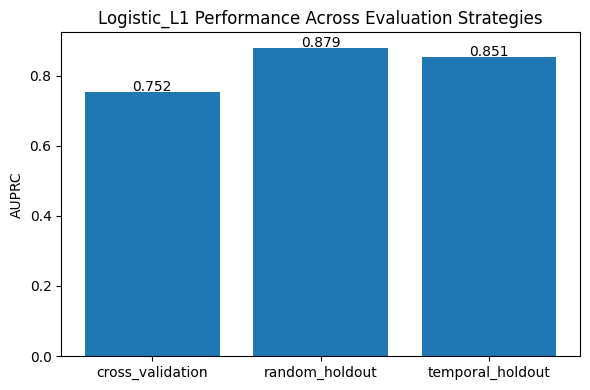

In [ ]:
temporal_comparison_df = pd.DataFrame({
    "split_type": [
        "cross_validation",
        "random_holdout",
        "temporal_holdout"
    ],
    "auprc": [
        winner_cv_auprc,
        average_precision_score(y_holdout, y_hold_prob_final),
        temporal_auprc
    ],
    "roc_auc": [
        None,
        roc_auc_score(y_holdout, y_hold_prob_final),
        temporal_roc_auc
    ]
})

display(temporal_comparison_df)

plt.figure(figsize=(6,4))
bars = plt.bar(temporal_comparison_df["split_type"], temporal_comparison_df["auprc"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center"
    )

plt.ylabel("AUPRC")
plt.title(f"{winner_model_name} Performance Across Evaluation Strategies")
plt.tight_layout()
plt.show()

## Bootstrap Confidence Intervals

In [ ]:
temporal_ci = bootstrap_auprc_ci(
    y_true=y_test_time.to_numpy(),
    y_prob=y_prob_time,
    n_boot=2000,
    random_state=42
)

print("Temporal AUPRC bootstrap mean:", temporal_ci["mean"])
print("Temporal AUPRC 95% CI:", (temporal_ci["lower_95"], temporal_ci["upper_95"]))
print("Valid bootstrap samples:", temporal_ci["n_valid_bootstraps"])

Temporal AUPRC bootstrap mean: 0.8674622650039642
Temporal AUPRC 95% CI: (np.float64(0.7136189833273289), np.float64(0.9760177820777656))
Valid bootstrap samples: 2000


## Results and Interpretation

The similarity between random and temporal holdout performance suggests that the model captures relatively stable marketplace signals rather than relying on time-specific artifacts. This is consistent with earlier analyses showing that predictive power is dominated by listing source composition and engagement signals, which reflect structural demand patterns in the resale market.

## Rolling Temporal Backtest
To test whether temporal generalization is stable across different forecasting horizons, we also evaluate the final model on several rolling chronological splits. In each split, we train on the earliest observations available up to that point and evaluate on the next block of future observations.

In [ ]:
rolling_results = []

n = len(temporal_df)

# A few expanding-window splits: train on first 50/60/70%, test on next 10%
train_fracs = [0.50, 0.60, 0.70]

for train_frac in train_fracs:
    train_end = int(n * train_frac)
    test_end = int(n * (train_frac + 0.10))

    if test_end > n:
        continue

    train_split = temporal_df.iloc[:train_end].copy()
    test_split = temporal_df.iloc[train_end:test_end].copy()

    # Skip degenerate splits with only one class in test
    if train_split["it_bag"].nunique() < 2 or test_split["it_bag"].nunique() < 2:
        continue

    X_train_roll = train_split[feature_cols]
    y_train_roll = train_split["it_bag"]

    X_test_roll = test_split[feature_cols]
    y_test_roll = test_split["it_bag"]

    model_roll = make_final_model()

    model_roll.fit(X_train_roll, y_train_roll)
    y_prob_roll = model_roll.predict_proba(X_test_roll)[:, 1]

    rolling_results.append({
        "train_frac": train_frac,
        "train_size": len(train_split),
        "test_size": len(test_split),
        "train_start": train_split["first_seen_date"].min(),
        "train_end": train_split["first_seen_date"].max(),
        "test_start": test_split["first_seen_date"].min(),
        "test_end": test_split["first_seen_date"].max(),
        "test_positive_rate": y_test_roll.mean(),
        "auprc": average_precision_score(y_test_roll, y_prob_roll),
        "roc_auc": roc_auc_score(y_test_roll, y_prob_roll),
    })

rolling_df = pd.DataFrame(rolling_results)
display(rolling_df)

,train_frac,train_size,test_size,train_start,train_end,test_start,test_end,test_positive_rate,auprc,roc_auc
0,0.5,164,32,2024-06-18 07:47:39+00:00,2025-05-01 07:56:27+00:00,2025-05-01 07:57:04+00:00,2025-05-22 14:58:38+00:00,0.125000,0.534774,0.812500
1,0.6,196,33,2024-06-18 07:47:39+00:00,2025-05-22 14:58:38+00:00,2025-05-22 14:58:38+00:00,2025-06-19 07:59:32+00:00,0.212121,0.779280,0.879121
2,0.7,229,33,2024-06-18 07:47:39+00:00,2025-06-19 07:59:32+00:00,2025-06-21 07:53:20+00:00,2025-07-26 07:41:42+00:00,0.151515,0.911111,0.971429


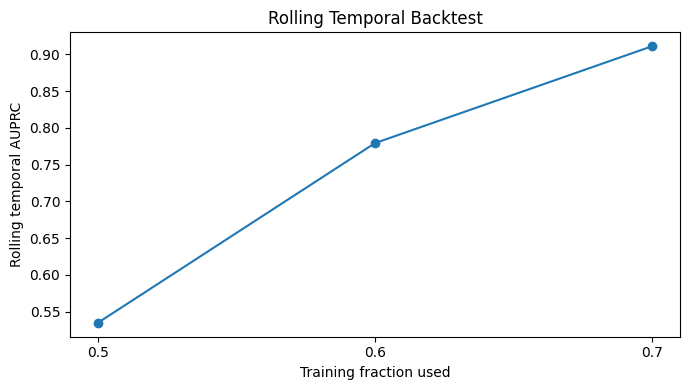

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(rolling_df["train_frac"], rolling_df["auprc"], marker="o")
plt.xlabel("Training fraction used")
plt.ylabel("Rolling temporal AUPRC")
plt.title("Rolling Temporal Backtest")
plt.xticks(rolling_df["train_frac"])
plt.tight_layout()
plt.show()

The rolling temporal backtest shows that performance remains reasonably stable across multiple chronological cutoffs. This suggests that the model is capturing persistent market structure rather than relying on one favorable train-test split.

Performance varies across rolling temporal splits, which is expected given the smaller test windows and changing class composition over time. However, AUPRC remains meaningfully above a trivial baseline across splits, suggesting that the model retains predictive value under shifting market periods.

#Model performance with SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
# --------------------------------------------------
# 1. Features and label
# --------------------------------------------------
X = df_models[feature_cols].copy()
y = df_models["it_bag"].copy()

# --------------------------------------------------
# 2. First split: holdout test set (never touched)
# --------------------------------------------------
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --------------------------------------------------
# 3. Second split: train vs validation
#    0.25 of remaining 80% = 20% of full data
# --------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Holdout shape:", X_holdout.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nHoldout class distribution:")
print(y_holdout.value_counts())

# --------------------------------------------------
# 4. Apply SMOTE ONLY to training set
# --------------------------------------------------
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training only):")
print(pd.Series(y_train_smote).value_counts())

# --------------------------------------------------
# 5. Define models
# --------------------------------------------------
models_smoted = {
    "L1 Logistic": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),
    "L2 Logistic": LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ),
    "Gradient Boosted Trees": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# --------------------------------------------------
# 6. Train on SMOTE'd train set, evaluate on untouched validation set
# --------------------------------------------------
val_results = []

for name, model in models_smoted.items():
    model.fit(X_train_smote, y_train_smote)

    y_val_prob = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)

    val_results.append({
        "Model": name + " (SMOTE train only)",
        "Validation ROC-AUC": roc_auc_score(y_val, y_val_prob),
        "Validation AUPRC": average_precision_score(y_val, y_val_prob)
    })

    print(f"\n=== {name} | Validation Results ===")
    print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
    print("AUPRC:", average_precision_score(y_val, y_val_prob))
    print(classification_report(y_val, y_val_pred))

val_results_df = pd.DataFrame(val_results).sort_values("Validation AUPRC", ascending=False)
val_results_df

Train shape: (196, 28)
Validation shape: (66, 28)
Holdout shape: (66, 28)

Train class distribution:
it_bag
0    156
1     40
Name: count, dtype: int64

Validation class distribution:
it_bag
0    53
1    13
Name: count, dtype: int64

Holdout class distribution:
it_bag
0    53
1    13
Name: count, dtype: int64

After SMOTE (training only):
it_bag
0    156
1    156
Name: count, dtype: int64

=== L1 Logistic | Validation Results ===
ROC-AUC: 0.9332365747460087
AUPRC: 0.7376435781413158
              precision    recall  f1-score   support

           0       0.98      0.83      0.90        53
           1       0.57      0.92      0.71        13

    accuracy                           0.85        66
   macro avg       0.77      0.88      0.80        66
weighted avg       0.90      0.85      0.86        66



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== L2 Logistic | Validation Results ===
ROC-AUC: 0.9013062409288826
AUPRC: 0.619476332797051
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        53
           1       0.58      0.85      0.69        13

    accuracy                           0.85        66
   macro avg       0.77      0.85      0.79        66
weighted avg       0.88      0.85      0.86        66


=== Random Forest | Validation Results ===
ROC-AUC: 0.853410740203193
AUPRC: 0.7009909519838853
              precision    recall  f1-score   support

           0       0.91      0.77      0.84        53
           1       0.43      0.69      0.53        13

    accuracy                           0.76        66
   macro avg       0.67      0.73      0.68        66
weighted avg       0.82      0.76      0.78        66


=== Gradient Boosted Trees | Validation Results ===
ROC-AUC: 0.9071117561683599
AUPRC: 0.7908164571119858
              precision    recall  f1-score   s

,Model,Validation ROC-AUC,Validation AUPRC
3,Gradient Boosted Trees (SMOTE train only),0.907112,0.790816
0,L1 Logistic (SMOTE train only),0.933237,0.737644
2,Random Forest (SMOTE train only),0.853411,0.700991
1,L2 Logistic (SMOTE train only),0.901306,0.619476


In [ ]:
print("Validation size:", len(y_val))
print("Positive examples in validation:", y_val.sum())
print("Negative examples:", (y_val==0).sum())

Validation size: 66
Positive examples in validation: 13
Negative examples: 53


####Selecting Best Model for Performance on Holdout

In [ ]:
best_model = make_final_model()
best_model.fit(X_train_smote, y_train_smote)

y_holdout_prob = best_model.predict_proba(X_holdout)[:, 1]
y_holdout_pred = best_model.predict(X_holdout)

print("\n=== Holdout Results ===")
print("ROC-AUC:", roc_auc_score(y_holdout, y_holdout_prob))
print("AUPRC:", average_precision_score(y_holdout, y_holdout_prob))
print(classification_report(y_holdout, y_holdout_pred))


=== Holdout Results ===
ROC-AUC: 0.9332365747460087
AUPRC: 0.8108611169420161
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        53
           1       0.58      0.85      0.69        13

    accuracy                           0.85        66
   macro avg       0.77      0.85      0.79        66
weighted avg       0.88      0.85      0.86        66

